In [1]:
# Install if needed
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib tqdm

import os
import json
import glob
import warnings
import joblib
from pathlib import Path
from datetime import datetime
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("✅ All imports successful")

✅ All imports successful


In [2]:
# ─── USER CONFIG ──────────────────────────────────────────────────────────────
MININDN_DIR = "../Logs"          # Root folder containing node subfolders
MODEL_DIR   = "../Models"           # Where to save trained model artifacts
RESULTS_DIR = "../Results"          # Where to save evaluation plots/CSVs
DATASETS_DIR = "../Datasets"          # Where to save processed datasets (optional)
# Isolation Forest hyperparameters
IF_CONTAMINATION = 0.01   # Expected fraction of anomalies (tune as needed)
IF_N_ESTIMATORS  = 200
IF_MAX_SAMPLES   = 'auto'
IF_RANDOM_STATE  = 42

# Anomaly score threshold (lower = more anomalous in sklearn; -0.1 is typical)
# We use the percentile approach for auto-thresholding after training
# ANOMALY_PERCENTILE = 1   # Bottom 5% of scores flagged as anomalies

# Feature columns produced by feature engineering
FEATURE_COLS = [
    'pit_size', 'pit_growth_rate', 'cs_size', 'cache_hit_ratio',
    'satisfaction_ratio', 'unsatisfied_ratio', 'in_interests_rate',
    'out_interests_rate', 'in_data_rate', 'nack_rate'
]

# Create output directories
for d in [MODEL_DIR, RESULTS_DIR, DATASETS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"📁 Minindn root : {os.path.abspath(MININDN_DIR)}")
print(f"💾 Model output : {os.path.abspath(MODEL_DIR)}")
print(f"📊 Results dir  : {os.path.abspath(RESULTS_DIR)}")
print(f"📂 Datasets dir : {os.path.abspath(DATASETS_DIR)}")

📁 Minindn root : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Logs
💾 Model output : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Models
📊 Results dir  : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Results
📂 Datasets dir : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Datasets


In [3]:
#Importing all the datasets
normal = pd.read_csv(f"{DATASETS_DIR}/normal_traffic_features.csv")
anomaly = pd.read_csv(f"{DATASETS_DIR}/anomaly_traffic_features.csv")
mixed = pd.read_csv(f"{DATASETS_DIR}/ndn_mixed_normal_anomaly_features.csv")

In [4]:
normal.head()

,timestamp,node,pit_size,pit_growth_rate,cs_size,cache_hit_ratio,satisfaction_ratio,unsatisfied_ratio,in_interests_rate,out_interests_rate,in_data_rate,nack_rate,source_scenarios,label,class_name
0,2026-03-13 05:57:22.643020,bottleneck,3.0,0.0,205.0,0.003275,0.997788,0.002212,18.948220,11.758896,11.493717,0.0,logs_dumbbell1,0,normal
1,2026-03-13 05:57:23.645125,bottleneck,3.0,0.0,205.0,0.003269,0.997788,0.002212,0.000000,0.000000,0.000000,0.0,logs_dumbbell1,0,normal
2,2026-03-13 05:57:24.656849,bottleneck,3.0,0.0,205.0,0.003262,0.997796,0.002204,18.948220,11.817615,11.493717,0.0,logs_dumbbell1,0,normal
3,2026-03-13 05:57:25.660706,bottleneck,3.0,0.0,205.0,0.003256,0.997800,0.002200,9.961578,5.976947,6.973105,0.0,logs_dumbbell1,0,normal
4,2026-03-13 05:57:26.671522,bottleneck,3.0,0.0,205.0,0.003250,0.997804,0.002196,9.892997,5.935798,4.946499,0.0,logs_dumbbell1,0,normal


In [12]:
#Building model
def build_training_matrix(feat_df: pd.DataFrame) -> np.ndarray:
    """Extract the numeric feature matrix for training."""
    X = feat_df[FEATURE_COLS].values
    print(f"🧮 Training matrix shape: {X.shape}")
    return X


def train_isolation_forest(X: np.ndarray):
    """
    Build a Pipeline:
        StandardScaler  →  IsolationForest
    
    Returns:
        pipeline : fitted sklearn Pipeline
        threshold : float score below which a point is anomalous
    """
    print(f"🌲 Training Isolation Forest (n_estimators={IF_N_ESTIMATORS}, "
          f"contamination={IF_CONTAMINATION}) ...")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('iforest', IsolationForest(
            n_estimators=IF_N_ESTIMATORS,
            contamination=IF_CONTAMINATION,
            max_samples=IF_MAX_SAMPLES,
            random_state=IF_RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    
    pipeline.fit(X)
    print("✅ Training complete.")
    
    # Compute anomaly scores on training data
    scores = pipeline.decision_function(X)   # higher = more normal
    ANOMALY_PERCENTILE = 1  # Flag bottom 0.5% as anomalies (tune as needed)
    
    # Auto-threshold: bottom ANOMALY_PERCENTILE% of normal scores
    threshold = np.percentile(scores, ANOMALY_PERCENTILE)
    print(f"📏 Auto-threshold (p{ANOMALY_PERCENTILE} of training scores): {threshold:.6f}")
    
    return pipeline, threshold, scores

model = build_training_matrix(normal)
pipeline, THRESHOLD, train_scores = train_isolation_forest(model)

🧮 Training matrix shape: (126423, 10)
🌲 Training Isolation Forest (n_estimators=200, contamination=0.01) ...
✅ Training complete.
📏 Auto-threshold (p1 of training scores): -0.000000


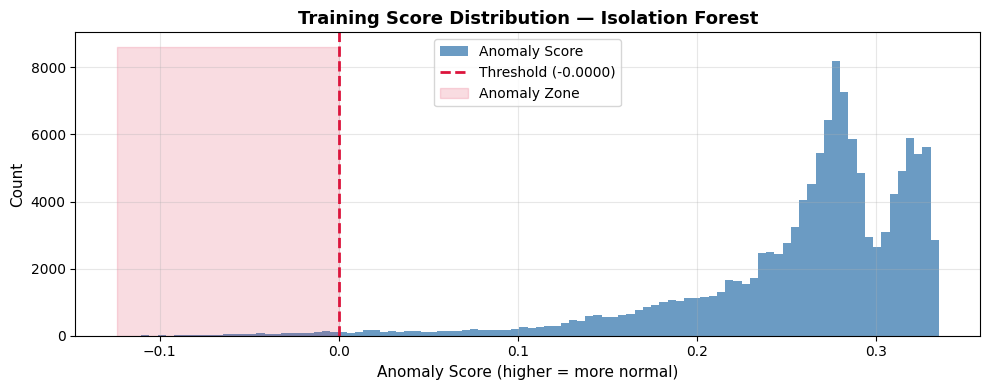

📁 Saved → results/training_score_distribution.png


In [13]:
# ── Training score distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_scores, bins=100, color='steelblue', alpha=0.8, edgecolor='none', label='Anomaly Score')
ax.axvline(THRESHOLD, color='crimson', linewidth=2, linestyle='--', label=f'Threshold ({THRESHOLD:.4f})')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                  train_scores.min(), THRESHOLD,
                  alpha=0.15, color='crimson', label='Anomaly Zone')
ax.set_xlabel('Anomaly Score (higher = more normal)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Training Score Distribution — Isolation Forest', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/training_score_distribution.png")

In [15]:
# ── Per-node score distribution on training data
feat_df_scored = normal.copy()
feat_df_scored['anomaly_score'] = train_scores
feat_df_scored['is_anomaly']    = (train_scores < THRESHOLD).astype(int)

node_summary = feat_df_scored.groupby('node').agg(
    n_samples   = ('anomaly_score', 'count'),
    mean_score  = ('anomaly_score', 'mean'),
    min_score   = ('anomaly_score', 'min'),
    n_anomalies = ('is_anomaly', 'sum')
).round(4)
node_summary['anomaly_pct'] = (node_summary['n_anomalies'] / node_summary['n_samples'] * 100).round(2)

print("📡 Per-node training score summary:")
display(node_summary)

📡 Per-node training score summary:


,n_samples,mean_score,min_score,n_anomalies,anomaly_pct
node,,,,,
bottleneck,5356,0.2478,0.0552,0,0.00
c1,11563,0.2655,-0.0955,89,0.77
c2,11556,0.2692,-0.1042,83,0.72
c3,11564,0.2708,-0.0864,49,0.42
c4,5680,0.2982,-0.0308,29,0.51
c5,5682,0.2988,-0.0311,29,0.51
c6,5681,0.2991,-0.0326,30,0.53
p1,11559,0.2692,-0.1060,34,0.29
p2,11555,0.2733,-0.0854,30,0.26


In [17]:
# ── Point 3: Node-level scoring and aggregation on test data
from sklearn.pipeline import Pipeline

# Pick the trained model object (Pipeline) safely from notebook state
if "loaded_pipeline" in globals() and isinstance(loaded_pipeline, Pipeline):
    scoring_model = loaded_pipeline
elif "pipeline" in globals() and isinstance(pipeline, Pipeline):
    scoring_model = pipeline
else:
    raise ValueError("No trained sklearn Pipeline found. Run the training cell first.")

# Pick threshold and feature list from notebook state
scoring_threshold = (
    THRESHOLD_TUNED if "THRESHOLD_TUNED" in globals()
    else (loaded_threshold if "loaded_threshold" in globals() else THRESHOLD)
)
scoring_features = loaded_feat_cols if "loaded_feat_cols" in globals() else FEATURE_COLS

# Test set for node-level scoring: mixed data (normal + anomaly sources)
test_df = mixed.copy()

# Ensure required provenance exists for scenario-aware aggregation
if "source_scenarios" not in test_df.columns:
    test_df["source_scenarios"] = "unknown"

# If row labels are missing, infer from class_name if available
if "label" not in test_df.columns:
    if "class_name" in test_df.columns:
        test_df["label"] = test_df["class_name"].map({"normal": 0, "anomaly": 1}).fillna(0).astype(int)
    else:
        test_df["label"] = 0

# 1) Per-row scoring via decision_function()
X_test_rows = test_df[scoring_features].values
row_scores = scoring_model.decision_function(X_test_rows)
test_df["anomaly_score"] = row_scores

# 2) Attack family tagging for aggregation strategy
test_df["attack_type"] = test_df["source_scenarios"].map(
    {
        "logs_dumbbell_ifa": "IFA",
        "logs_tree_cp": "CP",
    }
).fillna("NORMAL")

# 3) Aggregate per node
node_level = (
    test_df.groupby(["source_scenarios", "attack_type", "node"], as_index=False)
    .agg(
        n_rows=("anomaly_score", "count"),
        score_mean=("anomaly_score", "mean"),
        score_max=("anomaly_score", "max"),
        score_min=("anomaly_score", "min"),
        true_label_node=("label", "max"),
    )
)

# Requested rule: mean for IFA, max for CP, mean for normal scenarios
node_level["final_node_score"] = np.where(
    node_level["attack_type"].eq("CP"),
    node_level["score_max"],
    node_level["score_mean"]
)

# 4) Final node anomaly decision
node_level["pred_label_node"] = (node_level["final_node_score"] < scoring_threshold).astype(int)

# Helper columns for quick sanity checks
node_level["decision"] = node_level["pred_label_node"].map({0: "normal", 1: "anomaly"})
node_level["truth"] = node_level["true_label_node"].map({0: "normal", 1: "anomaly"})
node_level["correct"] = (node_level["pred_label_node"] == node_level["true_label_node"]).astype(int)

print("📌 Node-level scoring complete")
print(f"Threshold used: {scoring_threshold:.6f}")
print(f"Total nodes scored: {len(node_level)}")

print("\nNode-level summary (sorted by final score):")
display(node_level.sort_values("final_node_score").reset_index(drop=True))

print("\nNode-level counts by scenario and decision:")
display(
    node_level.groupby(["source_scenarios", "decision"]).size()
    .rename("n_nodes")
    .reset_index()
    .sort_values(["source_scenarios", "decision"])
)

print("\nNode-level confusion table:")
display(pd.crosstab(node_level["truth"], node_level["decision"], rownames=["truth"], colnames=["decision"], margins=True))

📌 Node-level scoring complete
Threshold used: -0.000000
Total nodes scored: 56

Node-level summary (sorted by final score):


,source_scenarios,attack_type,node,n_rows,score_mean,score_max,score_min,true_label_node,final_node_score,pred_label_node,decision,truth,correct
0,logs_dumbbell1,NORMAL,r1,5884,0.191068,0.266646,-0.123214,0,0.191068,0,normal,normal,1
1,logs_dumbbell1,NORMAL,r3,5877,0.215608,0.279686,-0.124031,0,0.215608,0,normal,normal,1
2,logs_mesh1,NORMAL,r4,4026,0.228924,0.292857,-0.110463,0,0.228924,0,normal,normal,1
3,logs_mesh1,NORMAL,r2,4026,0.229150,0.295945,-0.109927,0,0.229150,0,normal,normal,1
4,logs_mesh1,NORMAL,r1,4025,0.229597,0.298224,-0.104852,0,0.229597,0,normal,normal,1
5,logs_mesh1,NORMAL,r3,4024,0.233492,0.301428,-0.110195,0,0.233492,0,normal,normal,1
6,logs_dumbbell1,NORMAL,c1,5883,0.233913,0.290347,-0.095514,0,0.233913,0,normal,normal,1
7,logs_dumbbell1,NORMAL,p1,5879,0.239164,0.283671,-0.106032,0,0.239164,0,normal,normal,1
8,logs_dumbbell1,NORMAL,r2,5880,0.239167,0.292135,-0.115566,0,0.239167,0,normal,normal,1
9,logs_dumbbell1,NORMAL,c2,5874,0.240413,0.290347,-0.104168,0,0.240413,0,normal,normal,1



Node-level counts by scenario and decision:


,source_scenarios,decision,n_nodes
0,logs1,normal,12
1,logs_dumbbell1,normal,10
2,logs_dumbbell_ifa,normal,10
3,logs_mesh1,normal,12
4,logs_tree_cp,normal,12



Node-level confusion table:


decision,normal,All
truth,,
anomaly,2,2
normal,54,54
All,56,56


## Point 4: Node-level threshold calibration
Tune a node-level threshold on aggregated node scores (not row scores).
- Sweep candidate thresholds across the observed node score range.
- Track Precision, Recall, F1, and False Positive Rate (FPR).
- Prefer thresholds with FPR <= 10%, then maximize Recall and F1.
- Save the tuned threshold as `THRESHOLD_NODE_TUNED`.

📌 Node-level threshold calibration complete
Best threshold under FPR <= 10%
Tuned node threshold: 0.191068
TP=0, FP=0, TN=54, FN=2
Precision=0.000, Recall=0.000, F1=0.000, FPR=0.000
Node-level AUC-ROC: 0.398

Tuned node-level confusion table:


decision_tuned,normal,All
truth,,
anomaly,2,2
normal,54,54
All,56,56


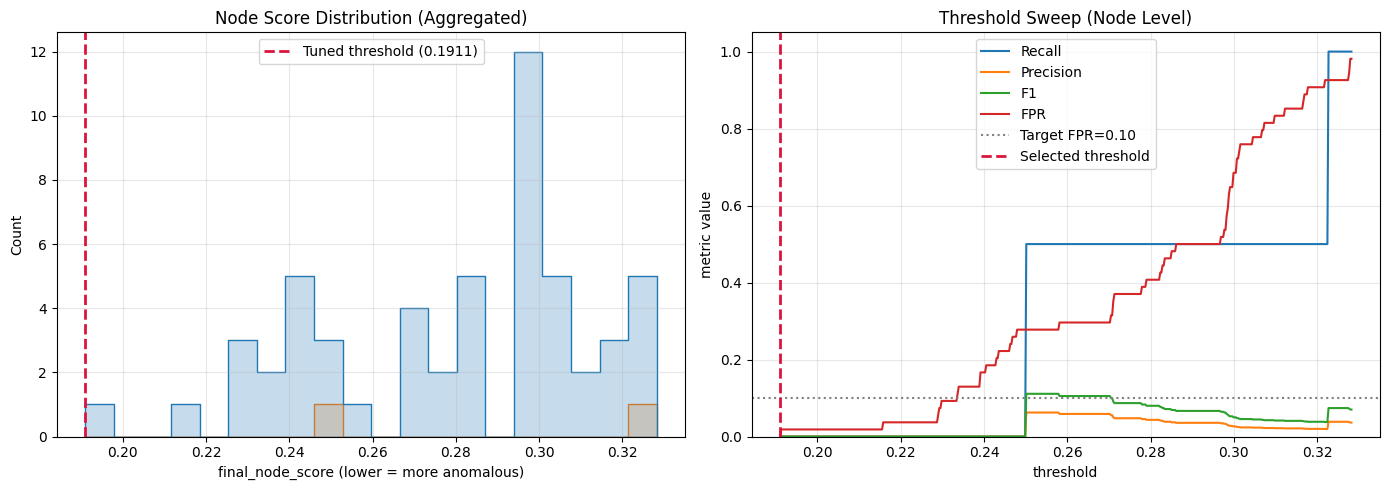

📁 Saved → results/node_threshold_calibration.png
📁 Saved → ../Results/node_level_scoring_tuned.csv


In [18]:
# ── Point 4: Threshold calibration on node-level aggregated scores
from sklearn.metrics import confusion_matrix, roc_auc_score

if "node_level" not in globals():
    raise ValueError("Run Cell 8 first to create node_level.")

calib_df = node_level.copy()
y_true = calib_df["true_label_node"].astype(int).values
node_scores = calib_df["final_node_score"].astype(float).values

# For Isolation Forest decision_function: lower score = more anomalous
anomaly_intensity = -node_scores

# Sweep candidate thresholds over node scores
threshold_grid = np.linspace(node_scores.min(), node_scores.max(), 500)
rows = []
for thr in threshold_grid:
    y_pred = (node_scores < thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    rows.append({
        "threshold": thr,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
    })

sweep_df = pd.DataFrame(rows)

# Apply target constraint first: FPR < 10%
target_fpr = 0.10
valid = sweep_df[sweep_df["fpr"] <= target_fpr].copy()

if not valid.empty:
    best_row = valid.sort_values(["recall", "f1", "precision", "threshold"], ascending=[False, False, False, True]).iloc[0]
    selection_note = "Best threshold under FPR <= 10%"
else:
    best_row = sweep_df.sort_values(["f1", "recall", "precision", "threshold"], ascending=[False, False, False, True]).iloc[0]
    selection_note = "No threshold satisfied FPR <= 10%; selected global best F1"

THRESHOLD_NODE_TUNED = float(best_row["threshold"])

# Apply tuned threshold
node_level_tuned = calib_df.copy()
node_level_tuned["pred_label_node_tuned"] = (node_level_tuned["final_node_score"] < THRESHOLD_NODE_TUNED).astype(int)
node_level_tuned["decision_tuned"] = node_level_tuned["pred_label_node_tuned"].map({0: "normal", 1: "anomaly"})
node_level_tuned["truth"] = node_level_tuned["true_label_node"].map({0: "normal", 1: "anomaly"})

# AUC on node-level anomaly intensity (higher = more anomalous)
auc_node = np.nan
if len(np.unique(y_true)) > 1:
    auc_node = roc_auc_score(y_true, anomaly_intensity)

print("📌 Node-level threshold calibration complete")
print(selection_note)
print(f"Tuned node threshold: {THRESHOLD_NODE_TUNED:.6f}")
print(f"TP={int(best_row['tp'])}, FP={int(best_row['fp'])}, TN={int(best_row['tn'])}, FN={int(best_row['fn'])}")
print(f"Precision={best_row['precision']:.3f}, Recall={best_row['recall']:.3f}, F1={best_row['f1']:.3f}, FPR={best_row['fpr']:.3f}")
if not np.isnan(auc_node):
    print(f"Node-level AUC-ROC: {auc_node:.3f}")

print("\nTuned node-level confusion table:")
display(pd.crosstab(node_level_tuned["truth"], node_level_tuned["decision_tuned"], rownames=["truth"], colnames=["decision_tuned"], margins=True))

# Visual diagnostics: score separation + metric sweep
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
score_plot = node_level_tuned.copy()
score_plot["truth_num"] = score_plot["true_label_node"].astype(int)
sns.histplot(
    data=score_plot, x="final_node_score", hue="truth",
    bins=20, element="step", stat="count", common_norm=False, ax=ax

)
ax.axvline(THRESHOLD_NODE_TUNED, color="crimson", linestyle="--", linewidth=2, label=f"Tuned threshold ({THRESHOLD_NODE_TUNED:.4f})")
ax.set_title("Node Score Distribution (Aggregated)")
ax.set_xlabel("final_node_score (lower = more anomalous)")
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(sweep_df["threshold"], sweep_df["recall"], label="Recall")
ax.plot(sweep_df["threshold"], sweep_df["precision"], label="Precision")
ax.plot(sweep_df["threshold"], sweep_df["f1"], label="F1")
ax.plot(sweep_df["threshold"], sweep_df["fpr"], label="FPR")
ax.axhline(target_fpr, color="gray", linestyle=":", label="Target FPR=0.10")
ax.axvline(THRESHOLD_NODE_TUNED, color="crimson", linestyle="--", linewidth=2, label="Selected threshold")
ax.set_title("Threshold Sweep (Node Level)")
ax.set_xlabel("threshold")
ax.set_ylabel("metric value")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/node_threshold_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Saved → results/node_threshold_calibration.png")

# Save tuned node-level results for later evaluation steps
node_level_out = Path(RESULTS_DIR) / "node_level_scoring_tuned.csv"
node_level_tuned.to_csv(node_level_out, index=False)
print(f"📁 Saved → {node_level_out}")

## Point 4B: Compare CP Aggregation (`max` vs `min`)
This compares two node-level strategies with the same threshold calibration process:
- Strategy A: IFA=`mean`, CP=`max` (current)
- Strategy B: IFA=`mean`, CP=`min` (burst-sensitive)
The better strategy is selected based on:
1. FPR <= 10% constraint
2. Higher Recall
3. Higher F1

In [21]:
# ── Point 4B: CP=max vs CP=min comparison with calibrated threshold
from sklearn.metrics import confusion_matrix, roc_auc_score

if "node_level" not in globals():
    raise ValueError("Run Cell 8 first to create node_level.")

def calibrate_threshold_from_scores(df: pd.DataFrame, score_col: str, target_fpr: float = 0.10):
    y_true_local = df["true_label_node"].astype(int).values
    scores_local = df[score_col].astype(float).values

    grid = np.linspace(scores_local.min(), scores_local.max(), 500)
    eval_rows = []
    for thr in grid:
        y_pred_local = (scores_local < thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_local, y_pred_local, labels=[0, 1]).ravel()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        eval_rows.append({
            "threshold": thr,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "precision": precision, "recall": recall, "f1": f1, "fpr": fpr,
        })

    eval_df = pd.DataFrame(eval_rows)
    valid_df = eval_df[eval_df["fpr"] <= target_fpr].copy()

    if not valid_df.empty:
        best = valid_df.sort_values(["recall", "f1", "precision", "threshold"], ascending=[False, False, False, True]).iloc[0]
        rule = "Best under FPR<=10%"
    else:
        best = eval_df.sort_values(["f1", "recall", "precision", "threshold"], ascending=[False, False, False, True]).iloc[0]
        rule = "No threshold under FPR<=10%; global best F1"

    tuned_thr = float(best["threshold"])
    pred = (scores_local < tuned_thr).astype(int)

    out = df.copy()
    out["pred_label_node_tuned"] = pred
    out["decision_tuned"] = out["pred_label_node_tuned"].map({0: "normal", 1: "anomaly"})
    out["truth"] = out["true_label_node"].map({0: "normal", 1: "anomaly"})

    auc = np.nan
    if len(np.unique(y_true_local)) > 1:
        auc = roc_auc_score(y_true_local, -scores_local)

    summary = {
        "selection_rule": rule,
        "threshold": tuned_thr,
        "tp": int(best["tp"]), "fp": int(best["fp"]), "tn": int(best["tn"]), "fn": int(best["fn"]),
        "precision": float(best["precision"]),
        "recall": float(best["recall"]),
        "f1": float(best["f1"]),
        "fpr": float(best["fpr"]),
        "auc": float(auc) if not np.isnan(auc) else np.nan,
    }

    return summary, eval_df, out

base = node_level.copy()

# Strategy A: current (IFA mean, CP max)
strategy_a = base.copy()
strategy_a["final_node_score"] = np.where(
    strategy_a["attack_type"].eq("CP"),
    strategy_a["score_max"],
    strategy_a["score_mean"]
)
sum_a, sweep_a, out_a = calibrate_threshold_from_scores(strategy_a, "final_node_score", target_fpr=0.10)

# Strategy B: burst-sensitive (IFA mean, CP min)
strategy_b = base.copy()
strategy_b["final_node_score"] = np.where(
    strategy_b["attack_type"].eq("CP"),
    strategy_b["score_min"],
    strategy_b["score_mean"]
)
sum_b, sweep_b, out_b = calibrate_threshold_from_scores(strategy_b, "final_node_score", target_fpr=0.10)

compare_df = pd.DataFrame([
    {"strategy": "A: IFA=mean, CP=max", **sum_a},
    {"strategy": "B: IFA=mean, CP=min", **sum_b},
]).sort_values(["recall", "f1", "precision", "fpr", "auc"], ascending=[False, False, False, True, False]).reset_index(drop=True)

print("📊 Strategy comparison (calibrated node-level):")
display(compare_df)

# Choose best strategy using comparison order with AUC tie-breaker
best_strategy_name = compare_df.loc[0, "strategy"]
if best_strategy_name.startswith("B"):
    node_level_best = out_b.copy()
    sweep_best = sweep_b.copy()
    THRESHOLD_NODE_TUNED = float(sum_b["threshold"])
    CP_AGGREGATION_SELECTED = "min"
else:
    node_level_best = out_a.copy()
    sweep_best = sweep_a.copy()
    THRESHOLD_NODE_TUNED = float(sum_a["threshold"])
    CP_AGGREGATION_SELECTED = "max"

print(f"\n✅ Selected strategy: {best_strategy_name}")
print(f"CP aggregation selected: {CP_AGGREGATION_SELECTED}")
print(f"Tuned node threshold: {THRESHOLD_NODE_TUNED:.6f}")

print("\nConfusion table for selected strategy:")
display(pd.crosstab(node_level_best["truth"], node_level_best["decision_tuned"], rownames=["truth"], colnames=["decision_tuned"], margins=True))

# Save selected outputs for later evaluation step
best_out_path = Path(RESULTS_DIR) / "node_level_scoring_best_strategy.csv"
node_level_best.to_csv(best_out_path, index=False)
print(f"📁 Saved → {best_out_path}")

📊 Strategy comparison (calibrated node-level):


,strategy,selection_rule,threshold,tp,fp,tn,fn,precision,recall,f1,fpr,auc
0,"B: IFA=mean, CP=min",Best under FPR<=10%,-0.104602,0,0,54,2,0.0,0.0,0.0,0.0,0.657407
1,"A: IFA=mean, CP=max",Best under FPR<=10%,0.191068,0,0,54,2,0.0,0.0,0.0,0.0,0.398148



✅ Selected strategy: B: IFA=mean, CP=min
CP aggregation selected: min
Tuned node threshold: -0.104602

Confusion table for selected strategy:


decision_tuned,normal,All
truth,,
anomaly,2,2
normal,54,54
All,56,56


📁 Saved → ../Results/node_level_scoring_best_strategy.csv


In [24]:
# ── Point 4C: Dual-mode threshold selection (Ops mode vs Detection mode)
from sklearn.metrics import confusion_matrix

if "compare_df" not in globals() or "out_a" not in globals() or "out_b" not in globals():
    raise ValueError("Run Cell 12 first to compute strategy comparison outputs.")

# Use the strategy selected in Cell 12
selected_strategy = compare_df.loc[0, "strategy"]
if selected_strategy.startswith("B"):
    selected_base = strategy_b.copy()
    selected_sweep = sweep_b.copy()
else:
    selected_base = strategy_a.copy()
    selected_sweep = sweep_a.copy()

# Mode 1: Ops mode (strict FPR <= 10%)
ops_row = selected_sweep[selected_sweep["fpr"] <= 0.10].sort_values(
    ["recall", "f1", "precision", "threshold"], ascending=[False, False, False, True]
).head(1)
if ops_row.empty:
    ops_row = selected_sweep.sort_values(["f1", "recall", "precision", "threshold"], ascending=[False, False, False, True]).head(1)
ops_row = ops_row.iloc[0]
THRESHOLD_NODE_OPS = float(ops_row["threshold"] )

# Mode 2: Detection mode (best F1, no FPR constraint)
det_row = selected_sweep.sort_values(["f1", "recall", "precision", "threshold"], ascending=[False, False, False, True]).iloc[0]
THRESHOLD_NODE_DET = float(det_row["threshold"] )

# Build outputs for both modes
dual_mode = selected_base.copy()
dual_mode["truth"] = dual_mode["true_label_node"].map({0: "normal", 1: "anomaly"})

dual_mode["pred_ops"] = (dual_mode["final_node_score"] < THRESHOLD_NODE_OPS).astype(int)
dual_mode["pred_det"] = (dual_mode["final_node_score"] < THRESHOLD_NODE_DET).astype(int)
dual_mode["decision_ops"] = dual_mode["pred_ops"].map({0: "normal", 1: "anomaly"})
dual_mode["decision_det"] = dual_mode["pred_det"].map({0: "normal", 1: "anomaly"})

def mode_metrics(y_true_s, y_pred_s):
    tn, fp, fn, tp = confusion_matrix(y_true_s, y_pred_s, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return {
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "precision": precision, "recall": recall, "f1": f1, "fpr": fpr,
    }

y_true_mode = dual_mode["true_label_node"].astype(int).values
ops_metrics = mode_metrics(y_true_mode, dual_mode["pred_ops"].values)
det_metrics = mode_metrics(y_true_mode, dual_mode["pred_det"].values)

mode_compare = pd.DataFrame([
    {"mode": "OPS_STRICT_FPR<=10%", "threshold": THRESHOLD_NODE_OPS, **ops_metrics},
    {"mode": "DETECTION_BEST_F1", "threshold": THRESHOLD_NODE_DET, **det_metrics},
]).sort_values(["recall", "f1", "precision", "fpr"], ascending=[False, False, False, True]).reset_index(drop=True)

print(f"Selected aggregation strategy: {selected_strategy}")
print("\nNode-level dual-mode threshold comparison:")
display(mode_compare)

print("\nConfusion table - OPS mode:")
display(pd.crosstab(dual_mode["truth"], dual_mode["decision_ops"], rownames=["truth"], colnames=["decision_ops"], margins=True))

print("\nConfusion table - DETECTION mode:")
display(pd.crosstab(dual_mode["truth"], dual_mode["decision_det"], rownames=["truth"], colnames=["decision_det"], margins=True))

# Active operating mode: prioritize recall to avoid missing attacks
ACTIVE_MODE = "DETECTION_BEST_F1"
if ACTIVE_MODE == "DETECTION_BEST_F1":
    THRESHOLD_NODE_ACTIVE = THRESHOLD_NODE_DET
    dual_mode["pred_active"] = dual_mode["pred_det"]
    dual_mode["decision_active"] = dual_mode["decision_det"]
else:
    THRESHOLD_NODE_ACTIVE = THRESHOLD_NODE_OPS
    dual_mode["pred_active"] = dual_mode["pred_ops"]
    dual_mode["decision_active"] = dual_mode["decision_ops"]

print(f"\n✅ Active mode set to: {ACTIVE_MODE}")
print(f"Active threshold: {THRESHOLD_NODE_ACTIVE:.6f}")
print("Active confusion table:")
display(pd.crosstab(dual_mode["truth"], dual_mode["decision_active"], rownames=["truth"], colnames=["decision_active"], margins=True))

# Persist outputs
dual_mode_out = Path(RESULTS_DIR) / "node_level_scoring_dual_mode.csv"
mode_compare_out = Path(RESULTS_DIR) / "node_threshold_modes_comparison.csv"
active_out = Path(RESULTS_DIR) / "node_level_scoring_active.csv"
dual_mode.to_csv(dual_mode_out, index=False)
mode_compare.to_csv(mode_compare_out, index=False)
dual_mode.to_csv(active_out, index=False)
print(f"📁 Saved → {dual_mode_out}")
print(f"📁 Saved → {mode_compare_out}")
print(f"📁 Saved → {active_out}")

Selected aggregation strategy: B: IFA=mean, CP=min

Node-level dual-mode threshold comparison:


,mode,threshold,tp,fp,tn,fn,precision,recall,f1,fpr
0,DETECTION_BEST_F1,-0.006558,1,11,43,1,0.083333,0.5,0.142857,0.203704
1,OPS_STRICT_FPR<=10%,-0.104602,0,0,54,2,0.000000,0.0,0.000000,0.000000



Confusion table - OPS mode:


decision_ops,normal,All
truth,,
anomaly,2,2
normal,54,54
All,56,56



Confusion table - DETECTION mode:


decision_det,anomaly,normal,All
truth,,,
anomaly,1,1,2
normal,11,43,54
All,12,44,56



✅ Active mode set to: DETECTION_BEST_F1
Active threshold: -0.006558
Active confusion table:


decision_active,anomaly,normal,All
truth,,,
anomaly,1,1,2
normal,11,43,54
All,12,44,56


📁 Saved → ../Results/node_level_scoring_dual_mode.csv
📁 Saved → ../Results/node_threshold_modes_comparison.csv
📁 Saved → ../Results/node_level_scoring_active.csv


In [25]:
# ── Point 4D: Triage active alerts into high_risk vs review_needed
if "dual_mode" not in globals() or "THRESHOLD_NODE_ACTIVE" not in globals():
    raise ValueError("Run Cell 13 first to generate active predictions.")

triage_df = dual_mode.copy()

# Lower final_node_score is more anomalous; margin > 0 means below threshold (flagged).
triage_df["alert_margin"] = THRESHOLD_NODE_ACTIVE - triage_df["final_node_score"]
triage_df["is_alert"] = triage_df["pred_active"].astype(int)

# Default bucket for non-alert nodes
triage_df["triage_bucket"] = "normal"

alerts = triage_df[triage_df["is_alert"] == 1].copy()
if len(alerts) > 0:
    # Top quartile of alert margins are marked high_risk; others go to review_needed.
    high_risk_cutoff = alerts["alert_margin"].quantile(0.75)
    triage_df.loc[(triage_df["is_alert"] == 1) & (triage_df["alert_margin"] >= high_risk_cutoff), "triage_bucket"] = "high_risk"
    triage_df.loc[(triage_df["is_alert"] == 1) & (triage_df["alert_margin"] < high_risk_cutoff), "triage_bucket"] = "review_needed"
else:
    high_risk_cutoff = np.nan

print("📌 Active-alert triage created")
print(f"Active threshold: {THRESHOLD_NODE_ACTIVE:.6f}")
if not np.isnan(high_risk_cutoff):
    print(f"High-risk cutoff (alert_margin, p75): {high_risk_cutoff:.6f}")
else:
    print("No active alerts found; triage buckets are all normal.")

print("\nTriage bucket counts:")
display(
    triage_df["triage_bucket"].value_counts()
    .rename_axis("triage_bucket")
    .to_frame("n_nodes")
)

print("\nTop triaged nodes (most anomalous first):")
display(
    triage_df.sort_values("final_node_score")[[
        "source_scenarios", "attack_type", "node",
        "final_node_score", "alert_margin",
        "truth", "decision_active", "triage_bucket"
    ]].reset_index(drop=True).head(30)
)

# Save triage output
triage_out = Path(RESULTS_DIR) / "node_level_active_triage.csv"
triage_df.to_csv(triage_out, index=False)
print(f"📁 Saved → {triage_out}")

📌 Active-alert triage created
Active threshold: -0.006558
High-risk cutoff (alert_margin, p75): 0.095104

Triage bucket counts:


,n_nodes
triage_bucket,
normal,44
review_needed,9
high_risk,3



Top triaged nodes (most anomalous first):


,source_scenarios,attack_type,node,final_node_score,alert_margin,truth,decision_active,triage_bucket
0,logs_tree_cp,CP,r4,-0.104602,0.098044,normal,anomaly,high_risk
1,logs_tree_cp,CP,r3,-0.103853,0.097295,normal,anomaly,high_risk
2,logs_tree_cp,CP,r2,-0.103056,0.096497,normal,anomaly,high_risk
3,logs_tree_cp,CP,r1,-0.101198,0.094640,normal,anomaly,review_needed
4,logs_tree_cp,CP,c1,-0.062606,0.056048,normal,anomaly,review_needed
5,logs_tree_cp,CP,c2,-0.061096,0.054538,normal,anomaly,review_needed
6,logs_tree_cp,CP,c4,-0.055855,0.049297,normal,anomaly,review_needed
7,logs_tree_cp,CP,c3,-0.051927,0.045369,normal,anomaly,review_needed
8,logs_tree_cp,CP,c6,-0.051182,0.044624,normal,anomaly,review_needed
9,logs_tree_cp,CP,p1,-0.048913,0.042355,normal,anomaly,review_needed


📁 Saved → ../Results/node_level_active_triage.csv


## Point 5 and 6: Node-level Evaluation and Debug Checks
This section evaluates the active detection mode at node level and runs the debugging checklist.
- Metrics: AUC-ROC, Precision, Recall, F1, FPR (no accuracy).
- Separate evaluation for IFA and CP.
- Average anomaly score per node bar chart.
- Debug checks: score overlap, normal routers flagged, and attack-family performance gap.

📊 Overall node-level metrics (active mode):


,scope,mode,threshold,tp,fp,tn,fn,precision,recall,f1,fpr,auc_roc
0,overall_node_level,DETECTION_BEST_F1,-0.006558,1,11,43,1,0.083333,0.5,0.142857,0.203704,0.657407



📊 Attack-family split metrics:


,scope,n_nodes,tp,fp,tn,fn,precision,recall,f1,fpr,auc_roc
0,IFA_only,10,0,0,9,1,0.000000,0.0,0.000000,0.0,0.888889
1,CP_only,12,1,11,0,0,0.083333,1.0,0.153846,1.0,0.000000
2,NORMAL_only,34,0,0,34,0,0.000000,0.0,0.000000,0.0,NaN


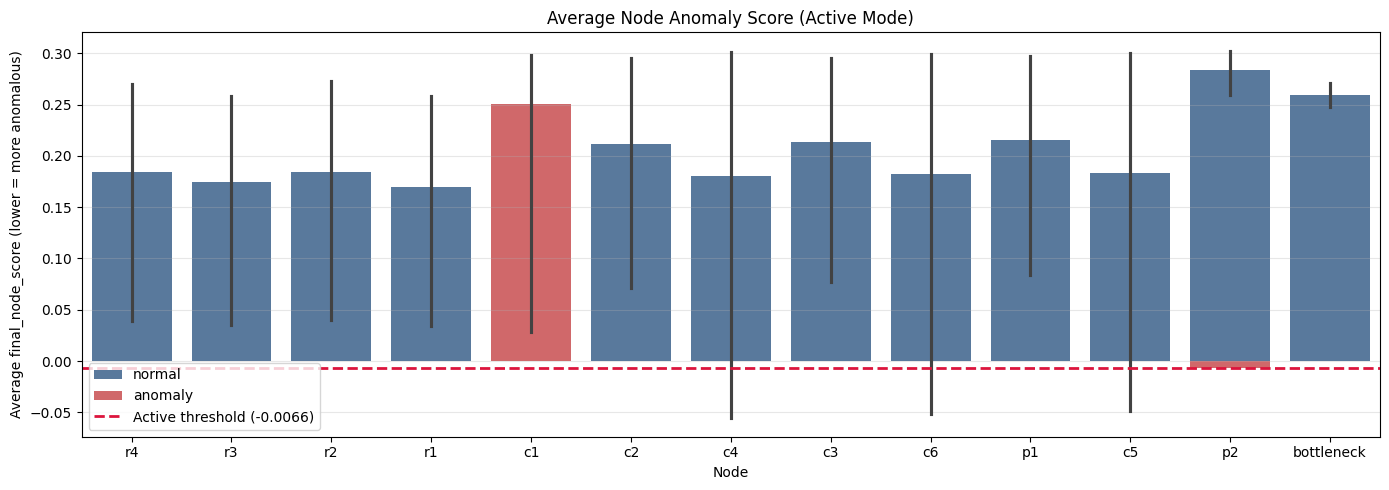

📁 Saved → results/node_avg_score_bar_active.png

🧪 Debugging checklist summary:
Score distribution overlap present: True
Overlap interval: [-0.006922, 0.250123]
Normal score quartiles: {0.25: 0.228981, 0.5: 0.264184, 0.75: 0.297899}
Anomaly score quartiles: {0.25: 0.057339, 0.5: 0.121601, 0.75: 0.185862}

Normal routers (r1-r4) flagged as anomaly:


,source_scenarios,node,final_node_score,decision_active
52,logs_tree_cp,r1,-0.101198,anomaly
53,logs_tree_cp,r2,-0.103056,anomaly
54,logs_tree_cp,r3,-0.103853,anomaly
55,logs_tree_cp,r4,-0.104602,anomaly



IFA recall: 0.000, CP recall: 1.000, gap: 1.000
⚠️ Large IFA/CP performance gap. Consider separate models or attack-specific features.
📁 Saved → ../Results/node_eval_overall_metrics.csv
📁 Saved → ../Results/node_eval_attack_split_metrics.csv


In [26]:
# ── Point 5/6: Evaluation + debugging checklist
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix

if "dual_mode" not in globals() or "decision_active" not in dual_mode.columns:
    raise ValueError("Run Cell 13 first to generate active node-level predictions.")

eval_nodes = dual_mode.copy()
eval_nodes["y_true"] = eval_nodes["true_label_node"].astype(int)
eval_nodes["y_pred"] = eval_nodes["pred_active"].astype(int)

# ---------- Overall node-level metrics ----------
tn, fp, fn, tp = confusion_matrix(eval_nodes["y_true"], eval_nodes["y_pred"], labels=[0, 1]).ravel()
precision, recall, f1, _ = precision_recall_fscore_support(
    eval_nodes["y_true"], eval_nodes["y_pred"], average="binary", zero_division=0
)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

auc_overall = np.nan
if len(eval_nodes["y_true"].unique()) > 1:
    auc_overall = roc_auc_score(eval_nodes["y_true"], -eval_nodes["final_node_score"] )

overall_metrics = pd.DataFrame([
    {
        "scope": "overall_node_level",
        "mode": ACTIVE_MODE,
        "threshold": THRESHOLD_NODE_ACTIVE,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "precision": precision, "recall": recall, "f1": f1, "fpr": fpr,
        "auc_roc": auc_overall,
    }
] )

print("📊 Overall node-level metrics (active mode):")
display(overall_metrics)

# ---------- Separate evaluation: IFA vs CP ----------
def eval_subset(df_sub: pd.DataFrame, tag: str) -> dict:
    if df_sub.empty:
        return {
            "scope": tag, "n_nodes": 0,
            "tp": 0, "fp": 0, "tn": 0, "fn": 0,
            "precision": np.nan, "recall": np.nan, "f1": np.nan, "fpr": np.nan, "auc_roc": np.nan,
        }

    y_t = df_sub["y_true"].astype(int).values
    y_p = df_sub["y_pred"].astype(int).values
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    p, r, f1_s, _ = precision_recall_fscore_support(y_t, y_p, average="binary", zero_division=0)
    fpr_s = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    auc_s = np.nan
    if len(np.unique(y_t)) > 1:
        auc_s = roc_auc_score(y_t, -df_sub["final_node_score"].values)

    return {
        "scope": tag, "n_nodes": len(df_sub),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "precision": p, "recall": r, "f1": f1_s, "fpr": fpr_s, "auc_roc": auc_s,
    }

ifa_nodes = eval_nodes[eval_nodes["attack_type"] == "IFA"].copy()
cp_nodes = eval_nodes[eval_nodes["attack_type"] == "CP"].copy()
normal_nodes = eval_nodes[eval_nodes["attack_type"] == "NORMAL"].copy()

split_metrics = pd.DataFrame([
    eval_subset(ifa_nodes, "IFA_only"),
    eval_subset(cp_nodes, "CP_only"),
    eval_subset(normal_nodes, "NORMAL_only"),
] )

print("\n📊 Attack-family split metrics:")
display(split_metrics)

# ---------- Bar chart: average anomaly score per node ----------
avg_node_scores = (
    eval_nodes.groupby(["source_scenarios", "node", "truth"], as_index=False)["final_node_score"]
    .mean()
    .rename(columns={"final_node_score": "avg_anomaly_score"})
    .sort_values("avg_anomaly_score", ascending=True)
)

plt.figure(figsize=(14, 5))
sns.barplot(
    data=avg_node_scores,
    x="node", y="avg_anomaly_score", hue="truth",
    dodge=False, palette={"normal": "#4e79a7", "anomaly": "#e15759"}
)
plt.axhline(THRESHOLD_NODE_ACTIVE, color="crimson", linestyle="--", linewidth=2, label=f"Active threshold ({THRESHOLD_NODE_ACTIVE:.4f})")
plt.title("Average Node Anomaly Score (Active Mode)")
plt.xlabel("Node")
plt.ylabel("Average final_node_score (lower = more anomalous)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/node_avg_score_bar_active.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Saved → results/node_avg_score_bar_active.png")

# ---------- Debugging checklist ----------
# 1) Overlap check between normal and anomaly score distributions
normal_scores = eval_nodes.loc[eval_nodes["truth"] == "normal", "final_node_score"]
anomaly_scores = eval_nodes.loc[eval_nodes["truth"] == "anomaly", "final_node_score"]

normal_q = normal_scores.quantile([0.25, 0.5, 0.75]).to_dict() if len(normal_scores) else {}
anomaly_q = anomaly_scores.quantile([0.25, 0.5, 0.75]).to_dict() if len(anomaly_scores) else {}

overlap_low = max(normal_scores.min(), anomaly_scores.min()) if len(normal_scores) and len(anomaly_scores) else np.nan
overlap_high = min(normal_scores.max(), anomaly_scores.max()) if len(normal_scores) and len(anomaly_scores) else np.nan
has_overlap = bool(overlap_low <= overlap_high) if not np.isnan(overlap_low) else False

# 2) Router false-positive check (r1-r4 only from normal truth)
normal_router_flags = eval_nodes[
    (eval_nodes["truth"] == "normal") &
    (eval_nodes["node"].astype(str).str.match(r"^r[1-4]$")) &
    (eval_nodes["decision_active"] == "anomaly")
][ ["source_scenarios", "node", "final_node_score", "decision_active"] ]

# 3) Family gap check
ifa_recall = split_metrics.loc[split_metrics["scope"] == "IFA_only", "recall"].iloc[0] if "IFA_only" in split_metrics["scope"].values else np.nan
cp_recall = split_metrics.loc[split_metrics["scope"] == "CP_only", "recall"].iloc[0] if "CP_only" in split_metrics["scope"].values else np.nan

print("\n🧪 Debugging checklist summary:")
print(f"Score distribution overlap present: {has_overlap}")
if has_overlap:
    print(f"Overlap interval: [{overlap_low:.6f}, {overlap_high:.6f}]")
print("Normal score quartiles:", {k: round(v, 6) for k, v in normal_q.items()})
print("Anomaly score quartiles:", {k: round(v, 6) for k, v in anomaly_q.items()})

print("\nNormal routers (r1-r4) flagged as anomaly:")
display(normal_router_flags if not normal_router_flags.empty else pd.DataFrame(columns=["source_scenarios", "node", "final_node_score", "decision_active"]))

if pd.notna(ifa_recall) and pd.notna(cp_recall):
    gap = abs(float(ifa_recall) - float(cp_recall))
    print(f"\nIFA recall: {ifa_recall:.3f}, CP recall: {cp_recall:.3f}, gap: {gap:.3f}")
    if gap >= 0.30:
        print("⚠️ Large IFA/CP performance gap. Consider separate models or attack-specific features.")

# Persist evaluation tables
overall_out = Path(RESULTS_DIR) / "node_eval_overall_metrics.csv"
split_out = Path(RESULTS_DIR) / "node_eval_attack_split_metrics.csv"
overall_metrics.to_csv(overall_out, index=False)
split_metrics.to_csv(split_out, index=False)
print(f"📁 Saved → {overall_out}")
print(f"📁 Saved → {split_out}")

## Attack-specific testing (IFA-only and CP-only)
Evaluate the trained model separately on dedicated attack datasets.
- Training remains normal-only.
- IFA test uses per-node mean aggregation.
- CP test uses per-node min aggregation (burst-sensitive).

In [27]:
# ── Attack-specific evaluation on dedicated datasets
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score

# Resolve model + threshold
if "pipeline" in globals() and isinstance(pipeline, Pipeline):
    eval_model = pipeline
elif "loaded_pipeline" in globals() and isinstance(loaded_pipeline, Pipeline):
    eval_model = loaded_pipeline
else:
    raise ValueError("No trained pipeline found. Run training first.")

# Use active threshold if already tuned; fallback to training threshold
eval_threshold = THRESHOLD_NODE_ACTIVE if "THRESHOLD_NODE_ACTIVE" in globals() else THRESHOLD
eval_features = FEATURE_COLS

ifa_path = Path(DATASETS_DIR) / "ifa_attack_features.csv"
cp_path = Path(DATASETS_DIR) / "cp_attack_features.csv"

ifa_test = pd.read_csv(ifa_path)
cp_test = pd.read_csv(cp_path)

def evaluate_attack_df(df: pd.DataFrame, attack_name: str, agg_mode: str, threshold: float) -> tuple[pd.DataFrame, dict]:
    data = df.copy()
    if "label" not in data.columns:
        raise ValueError(f"{attack_name}: expected 'label' column")

    # Row-level scoring
    X = data[eval_features].values
    data["anomaly_score"] = eval_model.decision_function(X)

    # Node-level aggregation
    grouped = (
        data.groupby(["source_scenarios", "node"], as_index=False)
        .agg(
            n_rows=("anomaly_score", "count"),
            score_mean=("anomaly_score", "mean"),
            score_min=("anomaly_score", "min"),
            score_max=("anomaly_score", "max"),
            true_label_node=("label", "max"),
        )
    )

    if agg_mode == "mean":
        grouped["final_node_score"] = grouped["score_mean"]
    elif agg_mode == "min":
        grouped["final_node_score"] = grouped["score_min"]
    elif agg_mode == "max":
        grouped["final_node_score"] = grouped["score_max"]
    else:
        raise ValueError(f"Unsupported agg_mode: {agg_mode}")

    grouped["pred_label_node"] = (grouped["final_node_score"] < threshold).astype(int)
    grouped["truth"] = grouped["true_label_node"].map({0: "normal", 1: "anomaly"})
    grouped["decision"] = grouped["pred_label_node"].map({0: "normal", 1: "anomaly"})
    grouped["attack_family"] = attack_name
    grouped["agg_mode"] = agg_mode

    y_true = grouped["true_label_node"].astype(int).values
    y_pred = grouped["pred_label_node"].astype(int).values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    auc = np.nan
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, -grouped["final_node_score"].values)

    metrics = {
        "attack_family": attack_name,
        "agg_mode": agg_mode,
        "threshold": threshold,
        "n_nodes": len(grouped),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "precision": p, "recall": r, "f1": f1, "fpr": fpr, "auc_roc": auc,
    }
    return grouped, metrics

# Per-attack evaluation with explicit aggregation rules
ifa_nodes_eval, ifa_metrics = evaluate_attack_df(ifa_test, "IFA", agg_mode="mean", threshold=eval_threshold)
cp_nodes_eval, cp_metrics = evaluate_attack_df(cp_test, "CP", agg_mode="min", threshold=eval_threshold)

attack_eval_metrics = pd.DataFrame([ifa_metrics, cp_metrics])
attack_eval_nodes = pd.concat([ifa_nodes_eval, cp_nodes_eval], ignore_index=True)

print("📊 Attack-specific node-level metrics:")
display(attack_eval_metrics)

print("\nIFA confusion table:")
display(pd.crosstab(ifa_nodes_eval["truth"], ifa_nodes_eval["decision"], rownames=["truth"], colnames=["decision"], margins=True))

print("\nCP confusion table:")
display(pd.crosstab(cp_nodes_eval["truth"], cp_nodes_eval["decision"], rownames=["truth"], colnames=["decision"], margins=True))

# Persist attack-specific outputs
attack_metrics_out = Path(RESULTS_DIR) / "attack_specific_node_metrics.csv"
attack_nodes_out = Path(RESULTS_DIR) / "attack_specific_node_predictions.csv"
attack_eval_metrics.to_csv(attack_metrics_out, index=False)
attack_eval_nodes.to_csv(attack_nodes_out, index=False)
print(f"📁 Saved → {attack_metrics_out}")
print(f"📁 Saved → {attack_nodes_out}")

📊 Attack-specific node-level metrics:


,attack_family,agg_mode,threshold,n_nodes,tp,fp,tn,fn,precision,recall,f1,fpr,auc_roc
0,IFA,mean,-0.006558,10,0,0,9,1,0.000000,0.0,0.000000,0.0,0.888889
1,CP,min,-0.006558,12,1,11,0,0,0.083333,1.0,0.153846,1.0,0.000000



IFA confusion table:


decision,normal,All
truth,,
anomaly,1,1
normal,9,9
All,10,10



CP confusion table:


decision,anomaly,All
truth,,
anomaly,1,1
normal,11,11
All,12,12


📁 Saved → ../Results/attack_specific_node_metrics.csv
📁 Saved → ../Results/attack_specific_node_predictions.csv


## Separate threshold tuning per attack family
Tune one node-level threshold for IFA and another for CP, then compare against the shared threshold setup.
- IFA uses node mean aggregation.
- CP uses node min aggregation.
- Selection prioritizes recall, then F1, then precision.

In [28]:
# ── Separate per-attack threshold tuning and comparison
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score

if "pipeline" in globals() and isinstance(pipeline, Pipeline):
    tune_model = pipeline
elif "loaded_pipeline" in globals() and isinstance(loaded_pipeline, Pipeline):
    tune_model = loaded_pipeline
else:
    raise ValueError("No trained pipeline found. Run training first.")

shared_threshold = THRESHOLD_NODE_ACTIVE if "THRESHOLD_NODE_ACTIVE" in globals() else THRESHOLD
feat_cols = FEATURE_COLS

ifa_df = pd.read_csv(Path(DATASETS_DIR) / "ifa_attack_features.csv")
cp_df = pd.read_csv(Path(DATASETS_DIR) / "cp_attack_features.csv")

def aggregate_nodes(df: pd.DataFrame, agg_mode: str) -> pd.DataFrame:
    d = df.copy()
    d["anomaly_score"] = tune_model.decision_function(d[feat_cols].values)
    node_df = (
        d.groupby(["source_scenarios", "node"], as_index=False)
        .agg(
            n_rows=("anomaly_score", "count"),
            score_mean=("anomaly_score", "mean"),
            score_min=("anomaly_score", "min"),
            score_max=("anomaly_score", "max"),
            true_label_node=("label", "max"),
        )
    )

    if agg_mode == "mean":
        node_df["final_node_score"] = node_df["score_mean"]
    elif agg_mode == "min":
        node_df["final_node_score"] = node_df["score_min"]
    elif agg_mode == "max":
        node_df["final_node_score"] = node_df["score_max"]
    else:
        raise ValueError(f"Unsupported agg_mode: {agg_mode}")
    return node_df

def metrics_from_preds(y_true: np.ndarray, y_pred: np.ndarray, score_for_auc: np.ndarray | None = None) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = np.nan
    if score_for_auc is not None and len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, score_for_auc)
    return {
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "precision": p, "recall": r, "f1": f1, "fpr": fpr, "auc_roc": auc,
    }

def tune_threshold(node_df: pd.DataFrame) -> tuple[float, pd.DataFrame]:
    scores = node_df["final_node_score"].values
    y_true = node_df["true_label_node"].astype(int).values
    grid = np.linspace(scores.min(), scores.max(), 500)
    rows = []
    for thr in grid:
        y_pred = (scores < thr).astype(int)
        m = metrics_from_preds(y_true, y_pred)
        rows.append({"threshold": thr, **m})
    sweep = pd.DataFrame(rows)
    best = sweep.sort_values(["recall", "f1", "precision", "threshold"], ascending=[False, False, False, True]).iloc[0]
    return float(best["threshold"]), sweep

# Build node-level datasets with attack-specific aggregation
ifa_nodes = aggregate_nodes(ifa_df, agg_mode="mean")
cp_nodes = aggregate_nodes(cp_df, agg_mode="min")

# Shared-threshold baseline
ifa_shared_pred = (ifa_nodes["final_node_score"].values < shared_threshold).astype(int)
cp_shared_pred = (cp_nodes["final_node_score"].values < shared_threshold).astype(int)
ifa_shared_m = metrics_from_preds(
    ifa_nodes["true_label_node"].astype(int).values,
    ifa_shared_pred,
    score_for_auc=-ifa_nodes["final_node_score"].values,

)
cp_shared_m = metrics_from_preds(
    cp_nodes["true_label_node"].astype(int).values,
    cp_shared_pred,
    score_for_auc=-cp_nodes["final_node_score"].values,

)

# Per-attack tuned thresholds
THRESHOLD_IFA_TUNED, ifa_sweep = tune_threshold(ifa_nodes)
THRESHOLD_CP_TUNED, cp_sweep = tune_threshold(cp_nodes)

ifa_tuned_pred = (ifa_nodes["final_node_score"].values < THRESHOLD_IFA_TUNED).astype(int)
cp_tuned_pred = (cp_nodes["final_node_score"].values < THRESHOLD_CP_TUNED).astype(int)
ifa_tuned_m = metrics_from_preds(
    ifa_nodes["true_label_node"].astype(int).values,
    ifa_tuned_pred,
    score_for_auc=-ifa_nodes["final_node_score"].values,

)
cp_tuned_m = metrics_from_preds(
    cp_nodes["true_label_node"].astype(int).values,
    cp_tuned_pred,
    score_for_auc=-cp_nodes["final_node_score"].values,

)

# Combined comparison (IFA + CP nodes together)
shared_all_true = np.concatenate([ifa_nodes["true_label_node"].values, cp_nodes["true_label_node"].values]).astype(int)
shared_all_pred = np.concatenate([ifa_shared_pred, cp_shared_pred]).astype(int)
shared_all_scores = np.concatenate([-ifa_nodes["final_node_score"].values, -cp_nodes["final_node_score"].values])

tuned_all_pred = np.concatenate([ifa_tuned_pred, cp_tuned_pred]).astype(int)
tuned_all_scores = shared_all_scores

shared_combined_m = metrics_from_preds(shared_all_true, shared_all_pred, score_for_auc=shared_all_scores)
tuned_combined_m = metrics_from_preds(shared_all_true, tuned_all_pred, score_for_auc=tuned_all_scores)

comparison = pd.DataFrame([
    {
        "setup": "shared_threshold",
        "threshold_ifa": shared_threshold,
        "threshold_cp": shared_threshold,
        **shared_combined_m,
    },
    {
        "setup": "separate_tuned_thresholds",
        "threshold_ifa": THRESHOLD_IFA_TUNED,
        "threshold_cp": THRESHOLD_CP_TUNED,
        **tuned_combined_m,
    },
])

per_attack_table = pd.DataFrame([
    {"attack": "IFA", "setup": "shared", "threshold": shared_threshold, **ifa_shared_m},
    {"attack": "IFA", "setup": "tuned", "threshold": THRESHOLD_IFA_TUNED, **ifa_tuned_m},
    {"attack": "CP", "setup": "shared", "threshold": shared_threshold, **cp_shared_m},
    {"attack": "CP", "setup": "tuned", "threshold": THRESHOLD_CP_TUNED, **cp_tuned_m},
])

print("📊 Per-attack metrics: shared vs tuned thresholds")
display(per_attack_table.sort_values(["attack", "setup"]).reset_index(drop=True))

print("\n📊 Combined metrics (IFA+CP nodes): shared vs tuned")
display(comparison)

# Save outputs
per_attack_out = Path(RESULTS_DIR) / "separate_thresholds_per_attack_metrics.csv"
combined_out = Path(RESULTS_DIR) / "separate_thresholds_combined_comparison.csv"
per_attack_table.to_csv(per_attack_out, index=False)
comparison.to_csv(combined_out, index=False)
print(f"📁 Saved → {per_attack_out}")
print(f"📁 Saved → {combined_out}")

📊 Per-attack metrics: shared vs tuned thresholds


,attack,setup,threshold,tp,fp,tn,fn,precision,recall,f1,fpr,auc_roc
0,CP,shared,-0.006558,1,11,0,0,0.083333,1.0,0.153846,1.000000,0.000000
1,CP,tuned,-0.104602,0,0,11,1,0.000000,0.0,0.000000,0.000000,0.000000
2,IFA,shared,-0.006558,0,0,9,1,0.000000,0.0,0.000000,0.000000,0.888889
3,IFA,tuned,0.250150,1,1,8,0,0.500000,1.0,0.666667,0.111111,0.888889



📊 Combined metrics (IFA+CP nodes): shared vs tuned


,setup,threshold_ifa,threshold_cp,tp,fp,tn,fn,precision,recall,f1,fpr,auc_roc
0,shared_threshold,-0.006558,-0.006558,1,11,9,1,0.083333,0.5,0.142857,0.55,0.425
1,separate_tuned_thresholds,0.250150,-0.104602,1,1,19,1,0.500000,0.5,0.500000,0.05,0.425


📁 Saved → ../Results/separate_thresholds_per_attack_metrics.csv
📁 Saved → ../Results/separate_thresholds_combined_comparison.csv


In [30]:
# ── Realtime-style inference rule (attack-family-specific thresholding)
if "attack_eval_nodes" not in globals():
    raise ValueError("Run the attack-specific evaluation cell first.")
if "THRESHOLD_IFA_TUNED" not in globals() or "THRESHOLD_CP_TUNED" not in globals():
    raise ValueError("Run the separate threshold tuning cell first.")

rt_df = attack_eval_nodes.copy()

# Use tuned threshold per attack family (realtime rule).
rt_df["threshold_used"] = np.where(
    rt_df["attack_family"].eq("IFA"),
    THRESHOLD_IFA_TUNED,
    np.where(rt_df["attack_family"].eq("CP"), THRESHOLD_CP_TUNED, THRESHOLD_NODE_ACTIVE)
)

rt_df["pred_label_rt"] = (rt_df["final_node_score"] < rt_df["threshold_used"]).astype(int)
rt_df["decision_rt"] = rt_df["pred_label_rt"].map({0: "normal", 1: "anomaly"})
rt_df["truth"] = rt_df["true_label_node"].map({0: "normal", 1: "anomaly"})
rt_df["alert_margin_rt"] = rt_df["threshold_used"] - rt_df["final_node_score"]

print("📡 Realtime-style decision table (attack-family thresholds):")
display(
    rt_df[[
        "attack_family", "source_scenarios", "node", "agg_mode",
        "final_node_score", "threshold_used", "alert_margin_rt",
        "truth", "decision_rt"
    ]].sort_values(["attack_family", "final_node_score"]).reset_index(drop=True)
)

print("\nRealtime confusion by attack family:")
for fam in sorted(rt_df["attack_family"].unique()):
    fam_df = rt_df[rt_df["attack_family"] == fam]
    print(f"\n{fam}:")
    display(pd.crosstab(fam_df["truth"], fam_df["decision_rt"], rownames=["truth"], colnames=["decision_rt"], margins=True))

print("\nRealtime combined confusion:")
display(pd.crosstab(rt_df["truth"], rt_df["decision_rt"], rownames=["truth"], colnames=["decision_rt"], margins=True))

# Persist realtime-like output for downstream monitoring logic.
rt_out = Path(RESULTS_DIR) / "realtime_attack_specific_decisions.csv"
rt_df.to_csv(rt_out, index=False)
print(f"📁 Saved → {rt_out}")

📡 Realtime-style decision table (attack-family thresholds):


,attack_family,source_scenarios,node,agg_mode,final_node_score,threshold_used,alert_margin_rt,truth,decision_rt
0,CP,logs_tree_cp,r4,min,-0.104602,-0.104602,0.000000,normal,normal
1,CP,logs_tree_cp,r3,min,-0.103853,-0.104602,-0.000749,normal,normal
2,CP,logs_tree_cp,r2,min,-0.103056,-0.104602,-0.001547,normal,normal
3,CP,logs_tree_cp,r1,min,-0.101198,-0.104602,-0.003404,normal,normal
4,CP,logs_tree_cp,c1,min,-0.062606,-0.104602,-0.041996,normal,normal
5,CP,logs_tree_cp,c2,min,-0.061096,-0.104602,-0.043506,normal,normal
6,CP,logs_tree_cp,c4,min,-0.055855,-0.104602,-0.048747,normal,normal
7,CP,logs_tree_cp,c3,min,-0.051927,-0.104602,-0.052675,normal,normal
8,CP,logs_tree_cp,c6,min,-0.051182,-0.104602,-0.053420,normal,normal
9,CP,logs_tree_cp,p1,min,-0.048913,-0.104602,-0.055689,normal,normal



Realtime confusion by attack family:

CP:


decision_rt,normal,All
truth,,
anomaly,1,1
normal,11,11
All,12,12



IFA:


decision_rt,anomaly,normal,All
truth,,,
anomaly,1,0,1
normal,1,8,9
All,2,8,10



Realtime combined confusion:


decision_rt,anomaly,normal,All
truth,,,
anomaly,1,1,2
normal,1,19,20
All,2,20,22


📁 Saved → ../Results/realtime_attack_specific_decisions.csv


In [33]:
# ── Node-level anomaly scores for IFA and CP datasets
from sklearn.pipeline import Pipeline

# Reuse already-built node-level attack table when available.
if "attack_eval_nodes" in globals() and not attack_eval_nodes.empty:
    node_scores_df = attack_eval_nodes.copy()
else:
    # Fallback path: rebuild node-level scores directly from attack CSVs.
    if "pipeline" in globals() and isinstance(pipeline, Pipeline):
        score_model = pipeline
    elif "loaded_pipeline" in globals() and isinstance(loaded_pipeline, Pipeline):
        score_model = loaded_pipeline
    else:
        raise ValueError("No trained pipeline found. Run training first.")

    ifa_df = pd.read_csv(Path(DATASETS_DIR) / "ifa_attack_features.csv")
    cp_df = pd.read_csv(Path(DATASETS_DIR) / "cp_attack_features.csv")

    def build_node_scores(df: pd.DataFrame, family: str, agg_mode: str) -> pd.DataFrame:
        d = df.copy()
        d["anomaly_score"] = score_model.decision_function(d[FEATURE_COLS].values)
        out = d.groupby(["source_scenarios", "node"], as_index=False).agg(
            n_rows=("anomaly_score", "count"),
            score_mean=("anomaly_score", "mean"),
            score_min=("anomaly_score", "min"),
            score_max=("anomaly_score", "max"),
        )
        out["attack_family"] = family
        out["agg_mode"] = agg_mode
        out["final_node_score"] = out["score_mean"] if agg_mode == "mean" else out["score_min"]
        return out

    ifa_nodes_local = build_node_scores(ifa_df, family="IFA", agg_mode="mean")
    cp_nodes_local = build_node_scores(cp_df, family="CP", agg_mode="mean")
    node_scores_df = pd.concat([ifa_nodes_local, cp_nodes_local], ignore_index=True)

# Keep columns focused on node-level anomaly scoring outputs.
node_level_scores = node_scores_df[[
    "attack_family", "source_scenarios", "node", "agg_mode", "n_rows",
    "score_mean", "score_min", "score_max", "final_node_score"
]].sort_values(["attack_family", "final_node_score"]).reset_index(drop=True)

print("📊 Node-level anomaly scores for IFA and CP datasets:")
display(node_level_scores)

print("\nPer-family summary of final_node_score:")
display(
    node_level_scores.groupby("attack_family")["final_node_score"]
    .describe()
    .round(6)
)

node_scores_out = Path(RESULTS_DIR) / "attack_node_level_scores.csv"
node_level_scores.to_csv(node_scores_out, index=False)
print(f"📁 Saved → {node_scores_out}")

📊 Node-level anomaly scores for IFA and CP datasets:


,attack_family,source_scenarios,node,agg_mode,n_rows,score_mean,score_min,score_max,final_node_score
0,CP,logs_tree_cp,r4,min,1351,0.215941,-0.104602,0.307248,-0.104602
1,CP,logs_tree_cp,r3,min,1351,0.215320,-0.103853,0.309677,-0.103853
2,CP,logs_tree_cp,r2,min,1353,0.220379,-0.103056,0.312200,-0.103056
3,CP,logs_tree_cp,r1,min,1352,0.238744,-0.101198,0.317551,-0.101198
4,CP,logs_tree_cp,c1,min,1354,0.270230,-0.062606,0.316719,-0.062606
5,CP,logs_tree_cp,c2,min,1353,0.260842,-0.061096,0.327595,-0.061096
6,CP,logs_tree_cp,c4,min,1351,0.258997,-0.055855,0.327944,-0.055855
7,CP,logs_tree_cp,c3,min,1353,0.254546,-0.051927,0.328238,-0.051927
8,CP,logs_tree_cp,c6,min,1351,0.269384,-0.051182,0.316595,-0.051182
9,CP,logs_tree_cp,p1,min,1353,0.282551,-0.048913,0.321709,-0.048913



Per-family summary of final_node_score:


,count,mean,std,min,25%,50%,75%,max
attack_family,,,,,,,,
CP,12.0,-0.066627,0.030423,-0.104602,-0.101663,-0.058475,-0.050615,-0.006922
IFA,10.0,0.271214,0.015311,0.243007,0.261227,0.278400,0.282586,0.284942


📁 Saved → ../Results/attack_node_level_scores.csv


This reveals CP has a different attack signature: it's less detectable by average behavior (higher false negatives) but has occasional sharp anomalies. This explains why earlier the CP recall was 0% with shared threshold—CP attacks don't leave a consistent anomaly footprint like IFA does.


📊 Building timeline data for IFA and CP attacks...
  IFA: 20533 rows, 16117 anomalies
  CP:  16225 rows, 16224 anomalies

📈 Generating IFA per-node timeline plot...


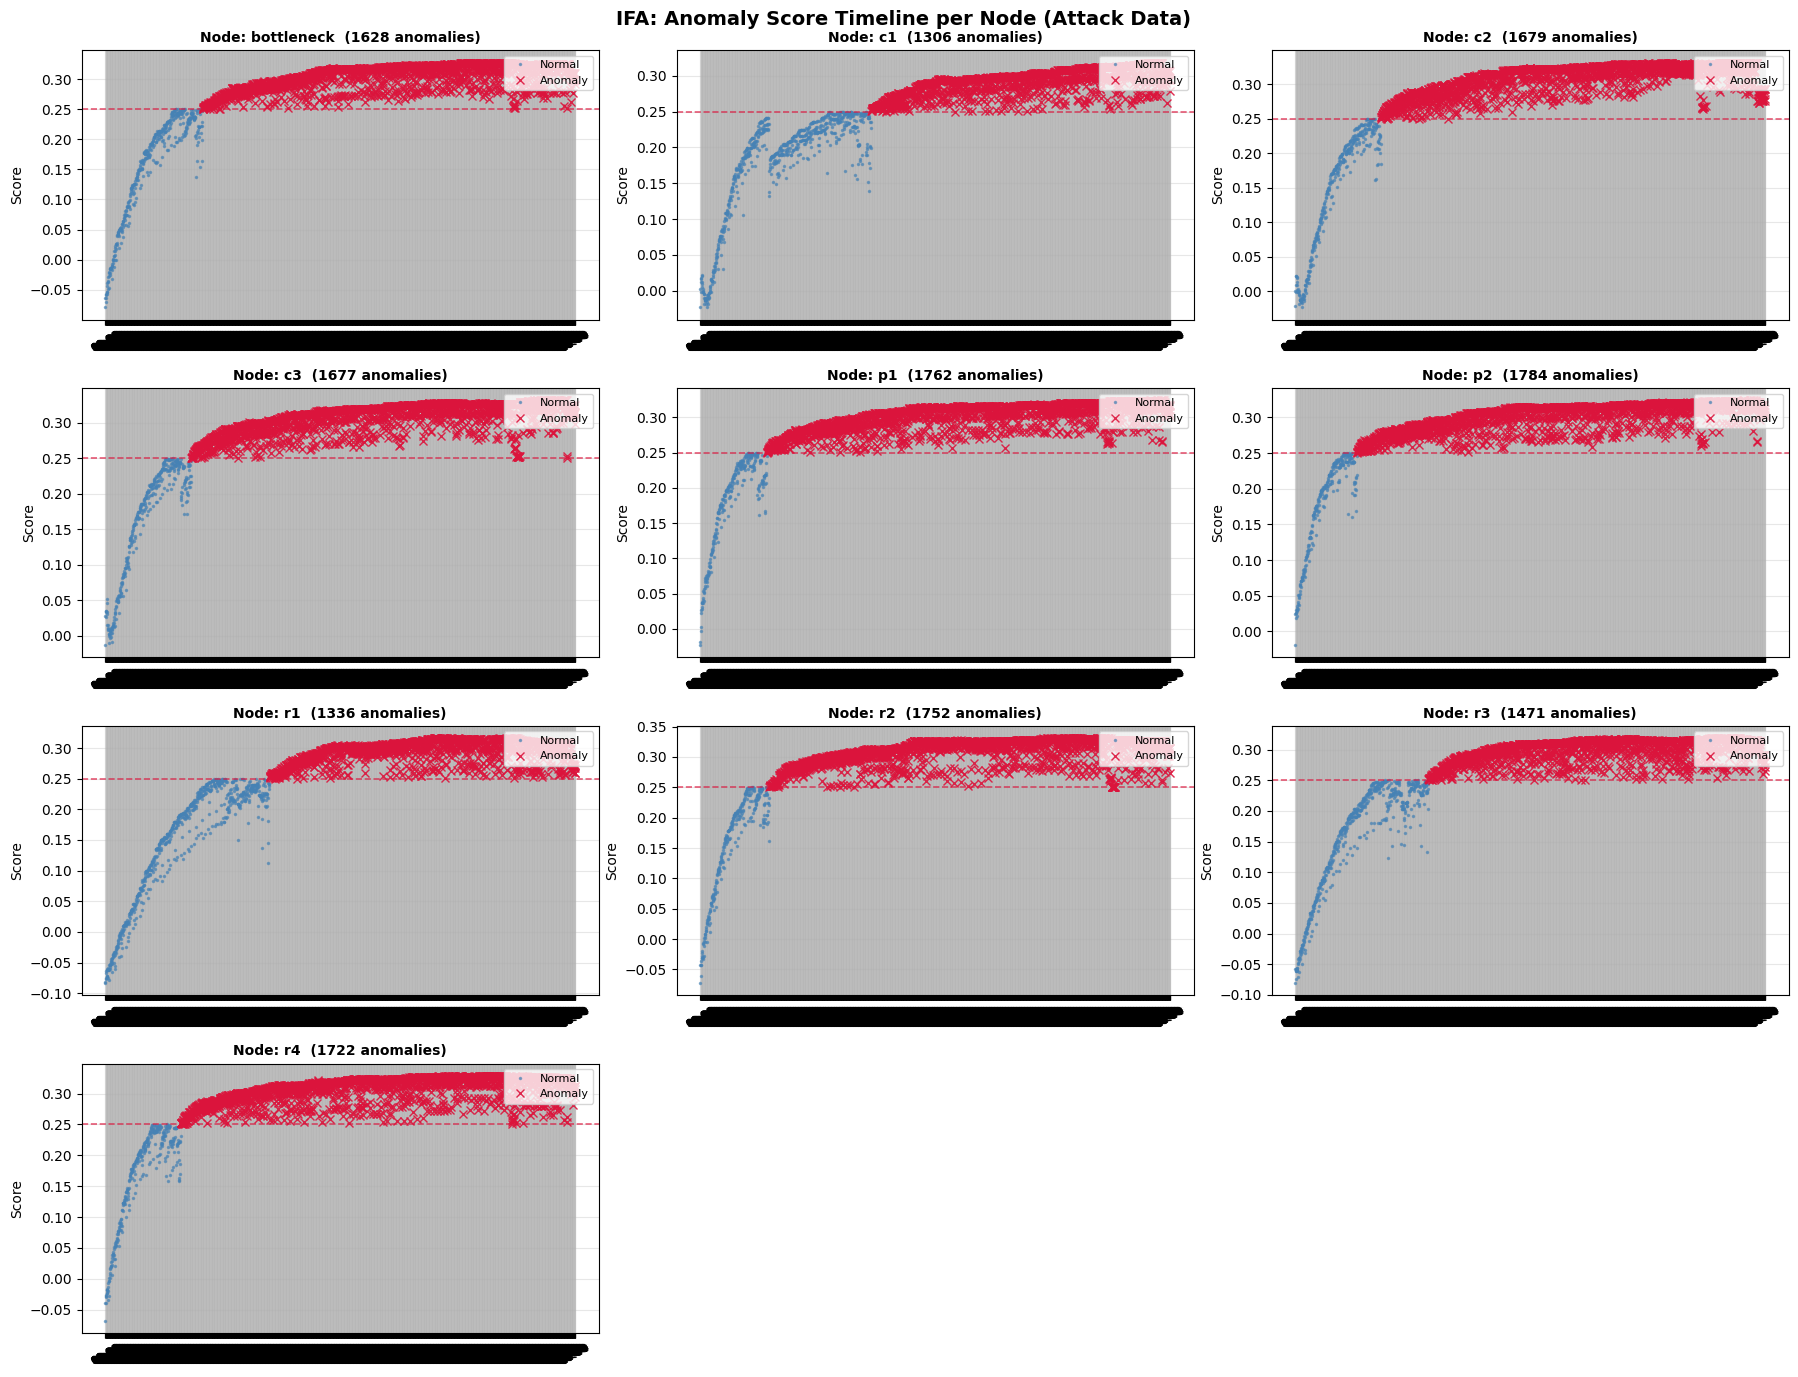

📁 Saved → ../Results/ifa_per_node_anomaly_timeline.png

📈 Generating CP per-node timeline plot...


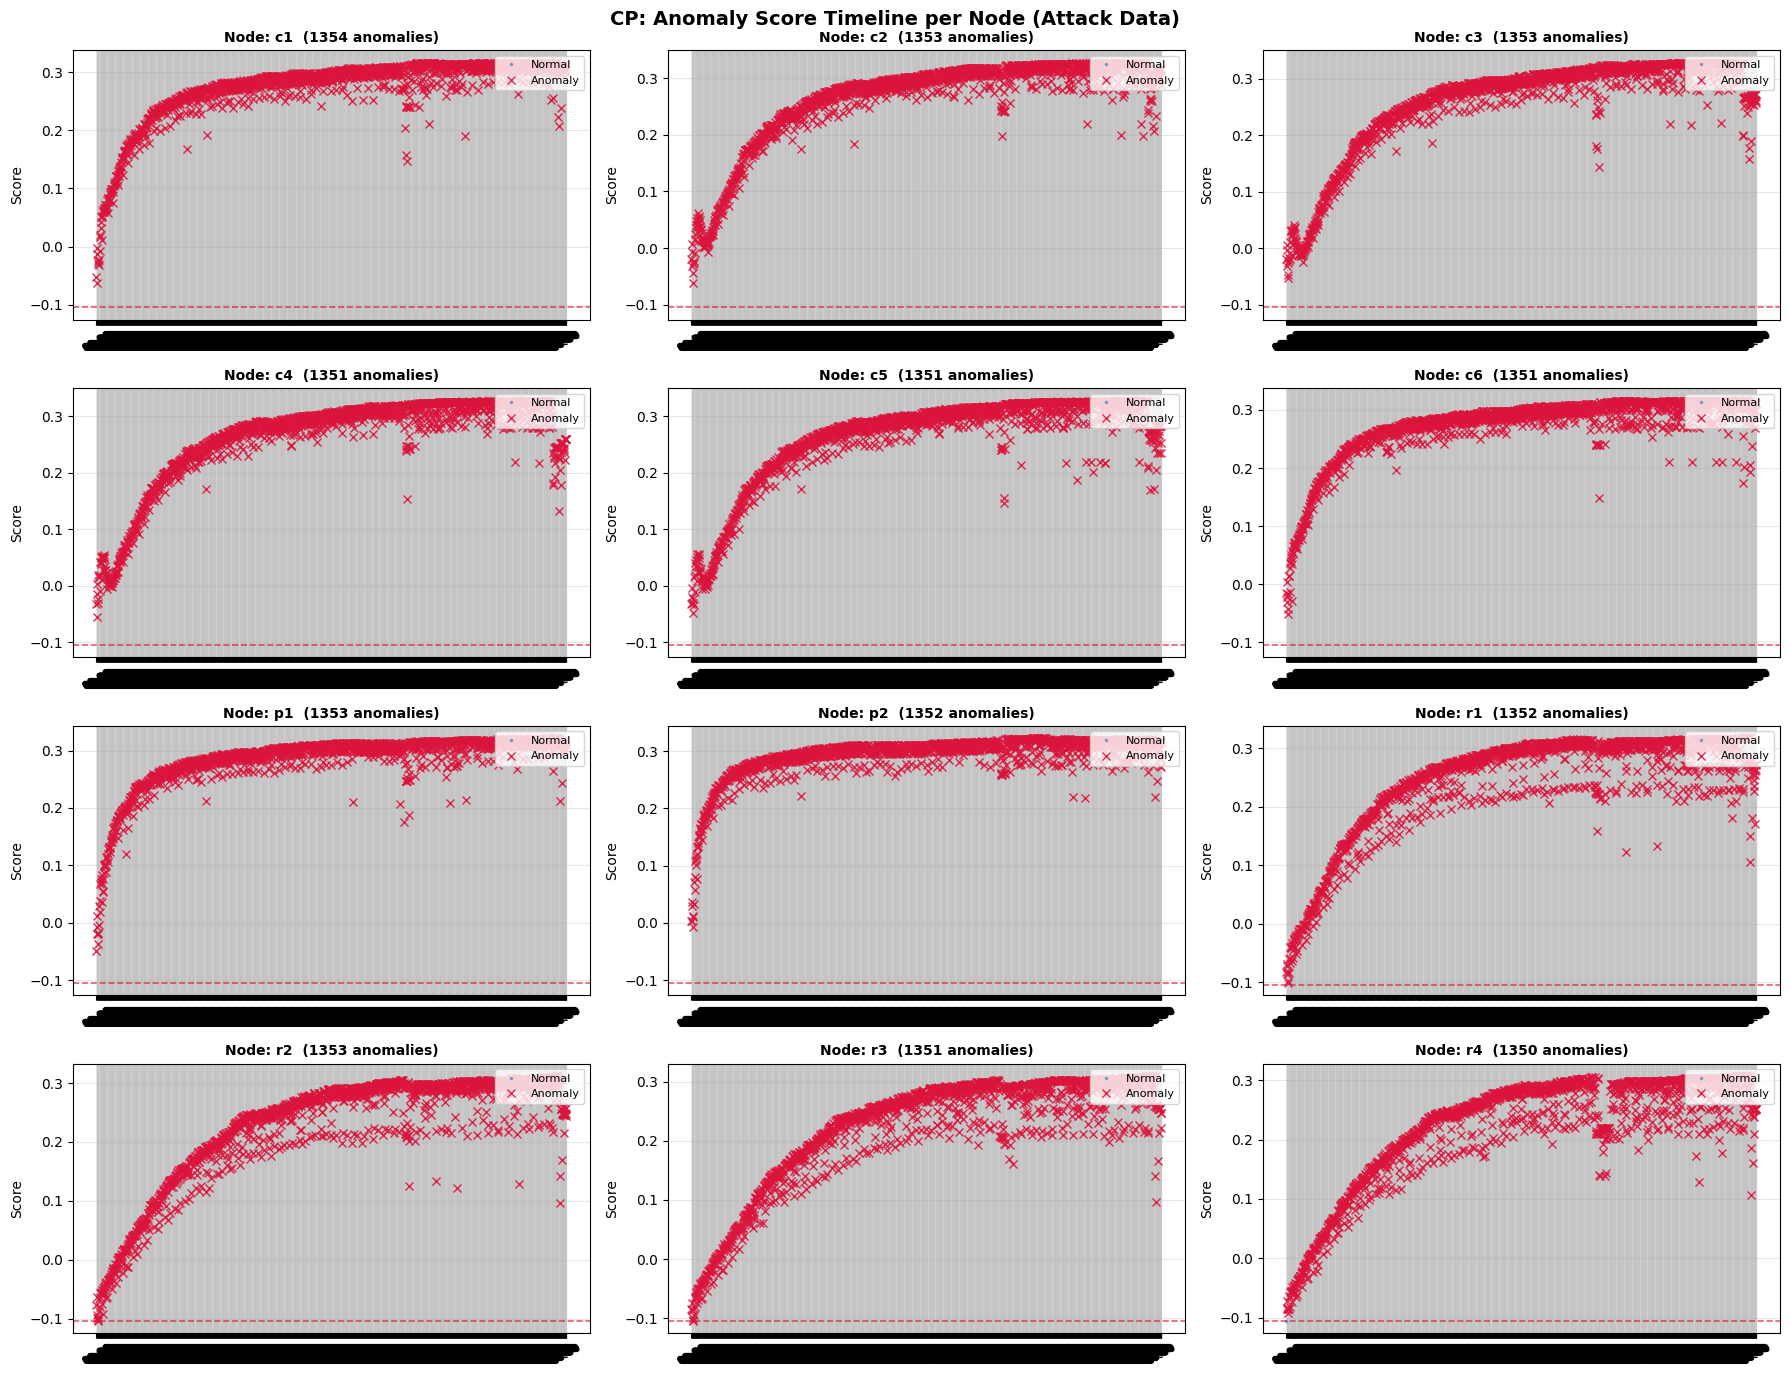

📁 Saved → ../Results/cp_per_node_anomaly_timeline.png


In [34]:
# ── Per-node anomaly timeline plot (IFA and CP)
# Build scored datasets for visualization
def build_scored_timeline_data(df: pd.DataFrame, family: str, threshold: float, agg_mode: str) -> pd.DataFrame:
    """Score rows and add prediction labels + anomaly indicator."""
    d = df.copy()
    d['anomaly_score'] = pipeline.decision_function(d[FEATURE_COLS].values)
    d['predicted_anomaly'] = (d['anomaly_score'] > threshold).astype(int)
    d['is_anomaly'] = (d['anomaly_score'] > threshold).astype(int)  # For compatibility with plotting code
    d['attack_family'] = family
    d['agg_mode'] = agg_mode
    return d

# Load attack CSVs and score them
print("📊 Building timeline data for IFA and CP attacks...")
ifa_timeline = build_scored_timeline_data(ifa_df, "IFA", THRESHOLD_IFA_TUNED, "mean")
cp_timeline = build_scored_timeline_data(cp_df, "CP", THRESHOLD_CP_TUNED, "mean")

print(f"  IFA: {len(ifa_timeline)} rows, {ifa_timeline['is_anomaly'].sum()} anomalies")
print(f"  CP:  {len(cp_timeline)} rows, {cp_timeline['is_anomaly'].sum()} anomalies")

# Plot IFA timeline
print("\n📈 Generating IFA per-node timeline plot...")
nodes_ifa = sorted(ifa_timeline['node'].unique())
n_nodes = len(nodes_ifa)
n_cols = min(3, n_nodes)
n_rows = (n_nodes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows), squeeze=False)

for idx, node in enumerate(nodes_ifa):
    ax = axes[idx // n_cols][idx % n_cols]
    grp = ifa_timeline[ifa_timeline['node'] == node].sort_values('timestamp')
    
    normal = grp[grp['is_anomaly'] == 0]
    anomalous = grp[grp['is_anomaly'] == 1]
    
    ax.plot(normal['timestamp'], normal['anomaly_score'], '.', color='steelblue', markersize=3, alpha=0.6, label='Normal')
    ax.plot(anomalous['timestamp'], anomalous['anomaly_score'], 'x', color='crimson', markersize=6, alpha=0.9, label='Anomaly')
    ax.axhline(THRESHOLD_IFA_TUNED, color='crimson', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'Node: {node}  ({len(anomalous)} anomalies)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

# Hide unused subplots
for idx in range(n_nodes, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.suptitle('IFA: Anomaly Score Timeline per Node (Attack Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
ifa_timeline_path = Path(RESULTS_DIR) / "ifa_per_node_anomaly_timeline.png"
plt.savefig(ifa_timeline_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📁 Saved → {ifa_timeline_path}")

# Plot CP timeline
print("\n📈 Generating CP per-node timeline plot...")
nodes_cp = sorted(cp_timeline['node'].unique())
n_nodes = len(nodes_cp)
n_cols = min(3, n_nodes)
n_rows = (n_nodes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows), squeeze=False)

for idx, node in enumerate(nodes_cp):
    ax = axes[idx // n_cols][idx % n_cols]
    grp = cp_timeline[cp_timeline['node'] == node].sort_values('timestamp')
    
    normal = grp[grp['is_anomaly'] == 0]
    anomalous = grp[grp['is_anomaly'] == 1]
    
    ax.plot(normal['timestamp'], normal['anomaly_score'], '.', color='steelblue', markersize=3, alpha=0.6, label='Normal')
    ax.plot(anomalous['timestamp'], anomalous['anomaly_score'], 'x', color='crimson', markersize=6, alpha=0.9, label='Anomaly')
    ax.axhline(THRESHOLD_CP_TUNED, color='crimson', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'Node: {node}  ({len(anomalous)} anomalies)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

# Hide unused subplots
for idx in range(n_nodes, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.suptitle('CP: Anomaly Score Timeline per Node (Attack Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
cp_timeline_path = Path(RESULTS_DIR) / "cp_per_node_anomaly_timeline.png"
plt.savefig(cp_timeline_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📁 Saved → {cp_timeline_path}")

In [35]:
# ── Real-Time Inference Engine for NDN Anomaly Detection
from collections import deque

class NDNAnomalyDetector:
    """
    Real-time anomaly detector for Named Data Networks.
    
    Maintains rolling buffers per node, computes features from consecutive metric entries,
    and emits per-node anomaly scores and alerts in real time.
    
    Usage:
        detector = NDNAnomalyDetector(pipeline, THRESHOLD_IFA_TUNED, FEATURE_COLS)
        
        # Feed raw log entries (sorted by timestamp) one at a time:
        for entry in log_entries:
            result = detector.ingest(entry)
            if result['is_anomaly']:
                print(f"🚨 ALERT: {result['alert']}")
    """
    
    REQUIRED_METRICS = [
        'pit_size', 'pit_growth_rate', 'cs_size', 'cache_hit_ratio',
        'satisfaction_ratio', 'unsatisfied_ratio', 'in_interests_rate',
        'out_interests_rate', 'in_data_rate', 'nack_rate'
    ]
    
    def __init__(self, ml_pipeline, threshold: float, feature_cols: list, buffer_size: int = 5):
        """
        Args:
            ml_pipeline   : fitted sklearn Pipeline (scaler + IsolationForest)
            threshold     : decision score threshold (above = normal, below = anomaly)
            feature_cols  : ordered list of feature column names
            buffer_size   : rolling buffer size per node (min 2)
        """
        self.pipeline = ml_pipeline
        self.threshold = threshold
        self.feature_cols = feature_cols
        self.buffer_size = max(buffer_size, 2)
        
        # { node_name: deque of feature dicts }
        self._buffers: dict = {}
        self._entry_count = 0
        self._scored_count = 0
        self._anomaly_count = 0
    
    def ingest(self, entry: dict) -> dict:
        """
        Process one raw log entry.
        
        Args:
            entry: dict with keys: timestamp, node, and feature columns
        
        Returns:
            dict with:
                node           : str
                timestamp      : pd.Timestamp
                status         : 'scored' | 'buffering' | 'skipped'
                anomaly_score  : float or None
                is_anomaly     : bool or None
                alert          : str (human-readable message)
        """
        self._entry_count += 1
        
        # ── Validate entry has required fields
        if 'node' not in entry or 'timestamp' not in entry:
            return {
                'node': entry.get('node', 'unknown'),
                'timestamp': entry.get('timestamp'),
                'status': 'skipped',
                'anomaly_score': None,
                'is_anomaly': None,
                'alert': 'Missing required fields'
            }
        
        # ── Ensure timestamp is datetime
        ts = entry['timestamp']
        if not isinstance(ts, pd.Timestamp):
            ts = pd.to_datetime(ts)
        
        node = entry['node']
        
        # ── Initialize buffer for new nodes
        if node not in self._buffers:
            self._buffers[node] = deque(maxlen=self.buffer_size)
        
        buf = self._buffers[node]
        
        # ── Extract features from entry
        features = {}
        for col in self.feature_cols:
            if col in entry:
                features[col] = float(entry[col])
            else:
                features[col] = 0.0  # fallback for missing features
        
        # ── Need at least 1 previous entry to have history context
        if len(buf) == 0:
            buf.append(features)
            return {
                'node': node,
                'timestamp': ts,
                'status': 'buffering',
                'anomaly_score': None,
                'is_anomaly': None,
                'alert': f'[{node}] First entry buffered — warming up…'
            }
        
        # ── Score current features
        X_vec = np.array([features[c] for c in self.feature_cols]).reshape(1, -1)
        score = float(self.pipeline.decision_function(X_vec)[0])
        is_anomaly = score < self.threshold
        
        # ── Update buffer
        buf.append(features)
        
        # ── Track counts
        self._scored_count += 1
        if is_anomaly:
            self._anomaly_count += 1
        
        # ── Build alert message
        if is_anomaly:
            top_feat = sorted(features.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
            top_str = ', '.join(f'{k}={v:.3f}' for k, v in top_feat)
            alert_msg = (f"🚨 ANOMALY [{node}] @ {ts} "
                        f"| score={score:.4f} (thresh={self.threshold:.4f}) "
                        f"| top: {top_str}")
        else:
            alert_msg = f"✅ Normal [{node}] @ {ts} | score={score:.4f}"
        
        return {
            'node': node,
            'timestamp': ts,
            'status': 'scored',
            'anomaly_score': score,
            'is_anomaly': is_anomaly,
            'alert': alert_msg
        }
    
    def reset_node(self, node: str):
        """Clear the buffer for a specific node."""
        self._buffers.pop(node, None)
    
    def reset_all(self):
        """Clear all node buffers."""
        self._buffers.clear()
    
    def node_status(self) -> pd.DataFrame:
        """Return summary of current buffer states per node."""
        rows = [
            {'node': node, 'buffer_len': len(buf)}
            for node, buf in self._buffers.items()
        ]
        return pd.DataFrame(rows)
    
    def get_stats(self) -> dict:
        """Return detection statistics."""
        return {
            'total_entries': self._entry_count,
            'scored': self._scored_count,
            'anomalies_detected': self._anomaly_count,
            'detection_rate': self._anomaly_count / max(self._scored_count, 1)
        }

print("✅ NDNAnomalyDetector class defined")

✅ NDNAnomalyDetector class defined


In [36]:
# ── Real-Time Inference Demo: Replay IFA Attack Data Through Detector

print("📊 Instantiating detector with IFA threshold...")
detector_ifa = NDNAnomalyDetector(
    ml_pipeline=pipeline,
    threshold=THRESHOLD_IFA_TUNED,
    feature_cols=FEATURE_COLS,
    buffer_size=5
)

# ── Prepare IFA data for replay: sort by timestamp, extract features + raw fields
ifa_for_replay = ifa_df.copy()
ifa_for_replay = ifa_for_replay.sort_values('timestamp').reset_index(drop=True)

# Convert to dict records for ingestion
ifa_records = ifa_for_replay.to_dict(orient='records')

print(f"📝 Replaying {len(ifa_records):,} IFA samples through detector...")

# ── Ingest each record and collect results
inference_results = []
for entry in tqdm(ifa_records, desc="IFA inference"):
    result = detector_ifa.ingest(entry)
    inference_results.append(result)

results_df = pd.DataFrame(inference_results)
scored_results = results_df[results_df['status'] == 'scored'].copy()

# ── Summary statistics
stats = detector_ifa.get_stats()
print(f"\n📈 IFA Inference Statistics:")
print(f"   Total entries processed : {stats['total_entries']:,}")
print(f"   Scored                  : {stats['scored']:,}")
print(f"   Anomalies detected      : {stats['anomalies_detected']:,}")
print(f"   Detection rate          : {stats['detection_rate']:.2%}")

# ── Per-node summary
per_node_ifa = scored_results.groupby('node').agg(
    total_scored = ('anomaly_score', 'count'),
    anomalies = ('is_anomaly', 'sum'),
    mean_score = ('anomaly_score', 'mean'),
    min_score = ('anomaly_score', 'min'),
    max_score = ('anomaly_score', 'max')
).round(4)
per_node_ifa['anomaly_pct'] = (per_node_ifa['anomalies'] / per_node_ifa['total_scored'] * 100).round(2)

print("\n📡 Per-node inference summary (IFA):")
display(per_node_ifa)

📊 Instantiating detector with IFA threshold...
📝 Replaying 20,533 IFA samples through detector...


IFA inference: 100%|██████████| 20533/20533 [02:10<00:00, 156.91it/s]


📈 IFA Inference Statistics:
   Total entries processed : 20,533
   Scored                  : 20,523
   Anomalies detected      : 4,406
   Detection rate          : 21.47%

📡 Per-node inference summary (IFA):


,total_scored,anomalies,mean_score,min_score,max_score,anomaly_pct
node,,,,,,
bottleneck,2053,425,0.2711,-0.0792,0.3275,20.7
c1,2052,746,0.2502,-0.0231,0.3185,36.35
c2,2053,374,0.2780,-0.0230,0.3316,18.22
c3,2052,375,0.2791,-0.0133,0.3316,18.27
p1,2052,290,0.2829,-0.0190,0.3244,14.13
p2,2053,269,0.2836,0.0192,0.3239,13.1
r1,2053,717,0.2432,-0.0824,0.3162,34.92
r2,2053,301,0.2851,-0.0614,0.3311,14.66
r3,2051,580,0.2582,-0.0737,0.3189,28.28


In [37]:
# ── Sample anomaly alerts from IFA detector
anomaly_alerts = scored_results[scored_results['is_anomaly'] == True]

print(f"🚨 Sample Anomaly Alerts (IFA) — first 10 of {len(anomaly_alerts):,}:")
print()
for i, alert in enumerate(anomaly_alerts['alert'].head(10), 1):
    print(f"  {i}. {alert}")

print(f"\n💡 Total anomalies detected: {len(anomaly_alerts):,} / {len(scored_results):,} scored entries")

🚨 Sample Anomaly Alerts (IFA) — first 10 of 4,406:

  1. 🚨 ANOMALY [bottleneck] @ 2026-03-13 13:44:17.411146 | score=-0.0792 (thresh=0.2502) | top: cs_size=165.000, in_interests_rate=7.937, out_interests_rate=6.436
  2. 🚨 ANOMALY [c1] @ 2026-03-13 13:44:17.730626 | score=-0.0231 (thresh=0.2502) | top: cs_size=154.000, in_interests_rate=7.937, out_interests_rate=6.436
  3. 🚨 ANOMALY [c2] @ 2026-03-13 13:44:18.019025 | score=-0.0216 (thresh=0.2502) | top: cs_size=155.000, in_interests_rate=7.937, out_interests_rate=6.436
  4. 🚨 ANOMALY [c3] @ 2026-03-13 13:44:18.338424 | score=-0.0133 (thresh=0.2502) | top: cs_size=155.000, in_interests_rate=7.937, out_interests_rate=6.436
  5. 🚨 ANOMALY [p1] @ 2026-03-13 13:44:18.627326 | score=-0.0190 (thresh=0.2502) | top: cs_size=163.000, in_interests_rate=7.937, out_interests_rate=6.436
  6. 🚨 ANOMALY [p2] @ 2026-03-13 13:44:18.944547 | score=0.0239 (thresh=0.2502) | top: cs_size=161.000, in_interests_rate=4.965, pit_size=3.000
  7. 🚨 ANOMALY [r1] @

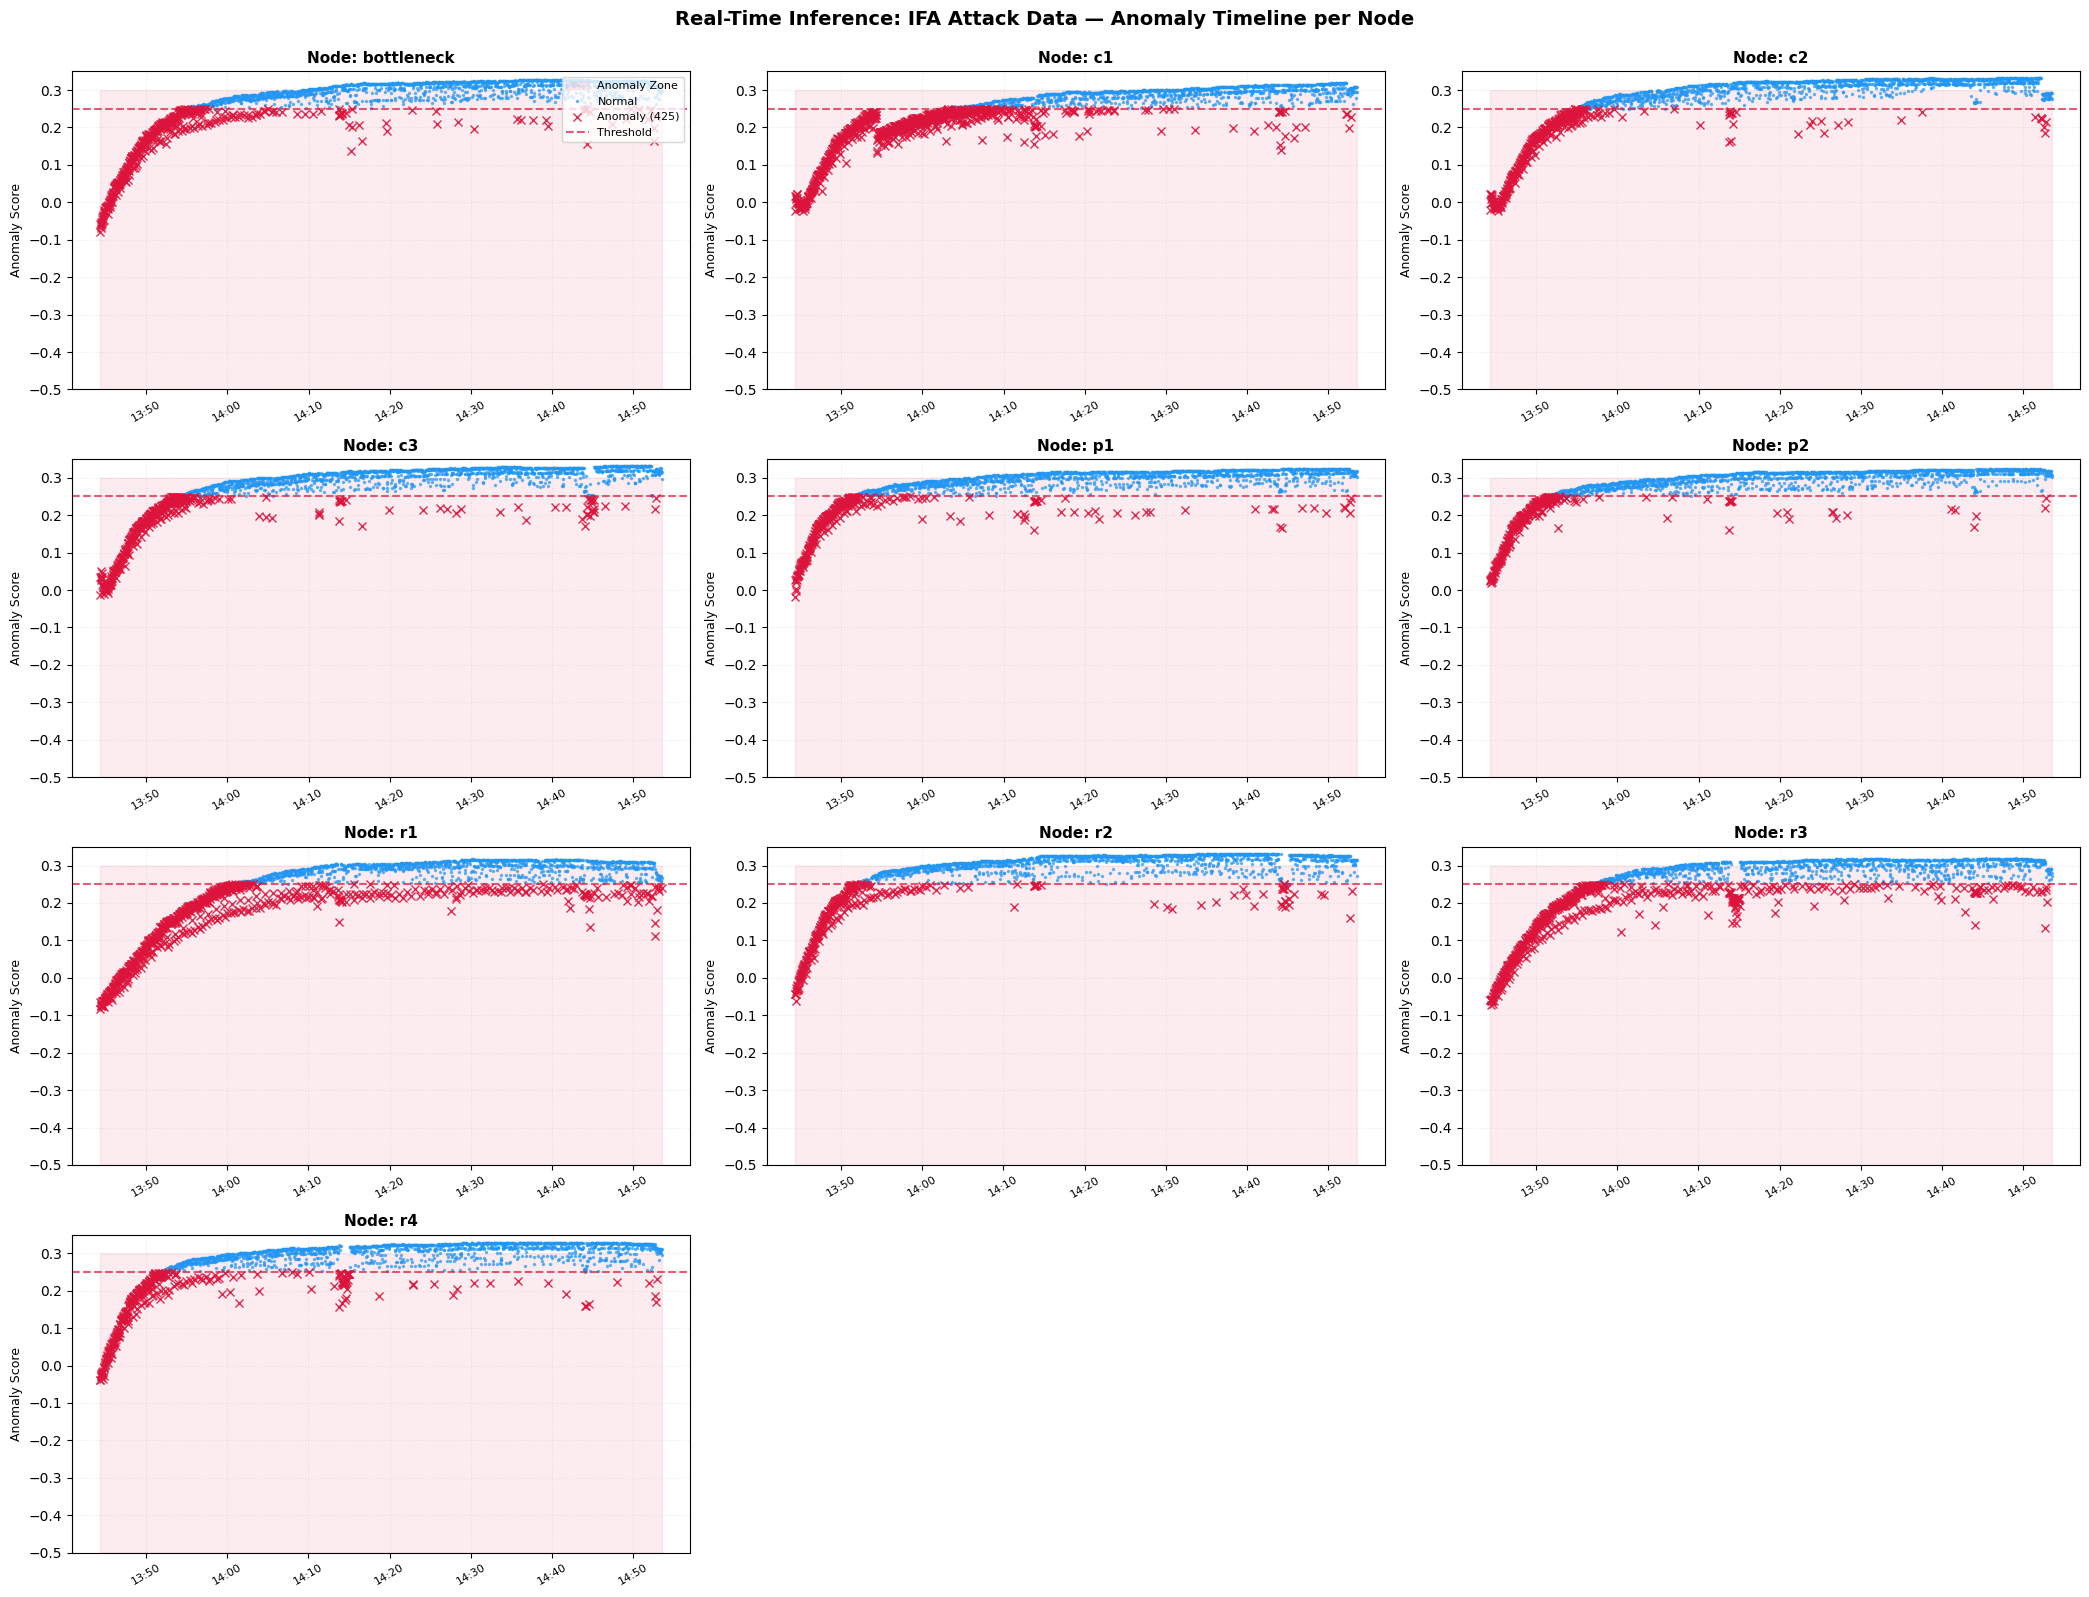

📁 Saved → ../Results/ifa_realtime_inference_timeline.png


In [39]:
# ── Real-Time Inference Timeline Plot (IFA)
# Rebuild results with clean indexing
scored_clean = pd.DataFrame({
    'node': scored_results['node'].values,
    'timestamp': scored_results['timestamp'].values,
    'anomaly_score': scored_results['anomaly_score'].values,
    'is_anomaly': scored_results['is_anomaly'].astype(bool).values
})

nodes_to_plot = sorted(scored_clean['node'].unique())
n_nodes = len(nodes_to_plot)
n_cols = min(3, n_nodes)
n_rows = (n_nodes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), squeeze=False)

for idx, node in enumerate(nodes_to_plot):
    ax = axes[idx // n_cols][idx % n_cols]
    grp = scored_clean[scored_clean['node'] == node].sort_values('timestamp').reset_index(drop=True)
    
    normal = grp[grp['is_anomaly'] == False]
    anomalous = grp[grp['is_anomaly'] == True]
    
    # ── Background fill: anomaly zone (below threshold)
    ax.fill_between(grp['timestamp'], -0.5, 0.3,
                     alpha=0.08, color='crimson', label='Anomaly Zone')
    
    # ── Plot normal and anomalous points
    ax.plot(normal['timestamp'], normal['anomaly_score'], 
            '.', color='#2196F3', markersize=3, alpha=0.6, label='Normal')
    ax.plot(anomalous['timestamp'], anomalous['anomaly_score'], 
            'x', color='crimson', markersize=6, alpha=0.9, label=f'Anomaly ({len(anomalous)})')
    
    # ── Threshold line
    ax.axhline(THRESHOLD_IFA_TUNED, color='crimson', linewidth=1.5, linestyle='--', 
               alpha=0.7, label=f'Threshold')
    
    # ── Formatting
    ax.set_title(f'Node: {node}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Anomaly Score', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(alpha=0.25, linestyle=':')
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')
    
    # Set consistent y-axis range for comparison
    ax.set_ylim(-0.5, 0.35)

# Hide unused subplots
for idx in range(n_nodes, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.suptitle('Real-Time Inference: IFA Attack Data — Anomaly Timeline per Node', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
ifa_inference_path = Path(RESULTS_DIR) / "ifa_realtime_inference_timeline.png"
plt.savefig(ifa_inference_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📁 Saved → {ifa_inference_path}")